# Bellabeat x Fitbit - Exploratory Data Analysis (EDA)

**Business task:** Bellabeat (a wellness-tech company for women) wants to know **how people use smart fitness trackers** so the marketing team can shape strategy for one Bellabeat product (app / Leaf / Time / Spring).

**Data:** Fitbit Fitness Tracker Data (Apr 12 - May 12, 2016), merged into a single **user-day table** (`fitbit_merged_daily.csv`: 940 rows x 45 columns, 33 users).

**Questions this notebook answers**
1. How active are users and how does activity change across weekdays / weekends?
2. How much of the day is spent sedentary?
3. How well do users sleep, and is sleep linked to activity?
4. What drives calorie burn?
5. Which user groups exist, and how consistently do they use the tracker?
6. What should Bellabeat's marketing team do with this?

**Contents:** 1 Setup - 2 Data overview - 3 Cleaning - 4 Distributions - 5 Weekday patterns - 6 Activity intensity - 7 Users & segments - 8 Sleep - 9 Calories - 10 Correlations - 11 Time trends - 12 Heart rate & weight - 13 Clustering - 14 Statistical tests - 15 Insights & recommendations

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- look & feel -------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PRIMARY, TEAL, PINK, AMBER, GREY = "#6C5CE7", "#00B894", "#FD79A8", "#FDCB6E", "#B2BEC3"
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})

# ---- locate the data (works from /notebooks or from the project root) ----
DATA = next(p for p in [Path("../data/fitbit_merged_daily.csv"),
                        Path("data/fitbit_merged_daily.csv"),
                        Path("fitbit_merged_daily.csv")] if p.exists())
WEEK = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
print("Using data file:", DATA)

Using data file: ../data/fitbit_merged_daily.csv


## 2. Data overview

In [2]:
df = pd.read_csv(DATA, parse_dates=["Date"])
print("Rows x columns:", df.shape)
print("Users:", df["Id"].nunique(), "| Dates:", df["Date"].min().date(), "->", df["Date"].max().date())
display(df.head())

Rows x columns: (940, 45)
Users: 33 | Dates: 2016-04-12 -> 2016-05-12
           Id       Date  TotalSteps  TotalDistance  TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes  Calories  TotalSleepRecords  TotalMinutesAsleep  TotalTimeInBed  WeightKg  WeightPounds  BodyFatPct  BMI WeightIsManual  WeightLogId  Hourly_TotalIntensity  Hourly_AvgIntensity  Hourly_Steps  Hourly_Calories  HoursLogged  Min_Steps_Sum  Min_Steps_Max  MinutesLogged  Min_Calories_Sum  Min_Calories_Max  Min_Intensity_Mean  Min_Intensity_Max  Min_METs_Mean  Min_METs_Max  MinSleep_Asleep  MinSleep_Restless  MinSleep_Awake  HR_Avg  HR_Min  HR_Max  HR_Readings
0  1503960366 2016-04-12       13162           8.50             8.50                       0.0                1.88                      0.55                 6.06                      0.0                 

In [3]:
# Column groups (from the merge): what each block of columns means
groups = {
    "Daily activity": ["TotalSteps", "TotalDistance", "VeryActiveMinutes", "FairlyActiveMinutes",
                       "LightlyActiveMinutes", "SedentaryMinutes", "Calories"],
    "Sleep":          ["TotalSleepRecords", "TotalMinutesAsleep", "TotalTimeInBed"],
    "Weight":         ["WeightKg", "BMI", "BodyFatPct"],
    "Heart rate":     ["HR_Avg", "HR_Min", "HR_Max"],
}
for g, cols in groups.items():
    print(f"{g:15s}: {df[cols].notna().all(axis=1).sum():4d} complete rows | {df.loc[df[cols].notna().all(axis=1), 'Id'].nunique():2d} users")

Daily activity :  940 complete rows | 33 users
Sleep          :  410 complete rows | 24 users
Weight         :    2 complete rows |  2 users
Heart rate     :  334 complete rows | 14 users


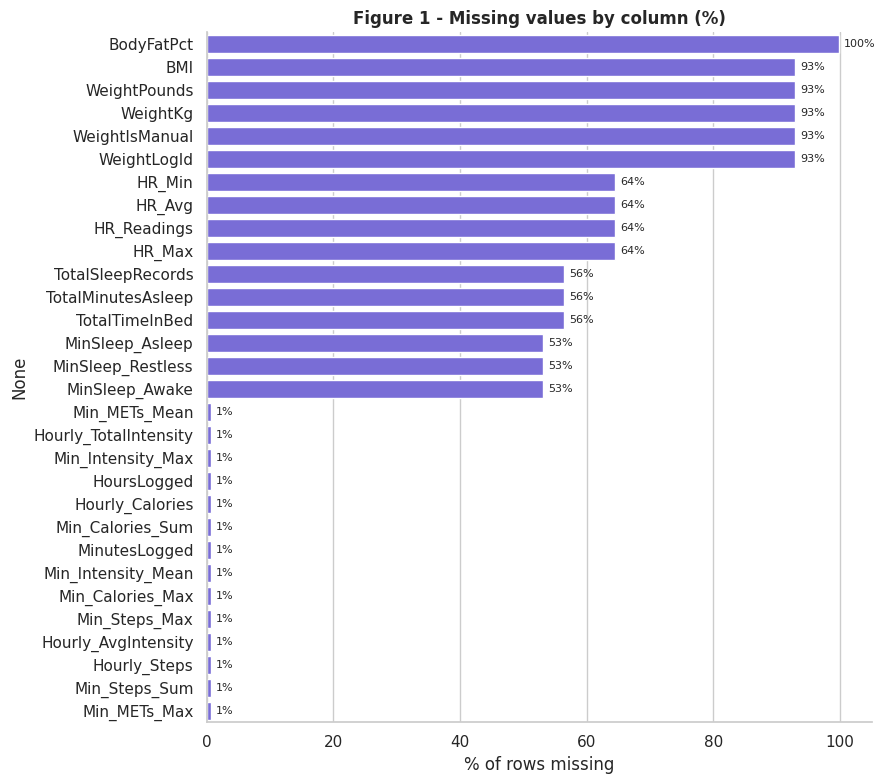

In [4]:
# Missing values - how much of each column is empty?
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=miss.values, y=miss.index, color=PRIMARY, ax=ax)
ax.set_title("Figure 1 - Missing values by column (%)")
ax.set_xlabel("% of rows missing")
for i, v in enumerate(miss.values):
    ax.text(v + 0.8, i, f"{v:.0f}%", va="center", fontsize=8)
ax.set_xlim(0, 105)
plt.tight_layout(); plt.show()

**Reading Figure 1:** sleep, weight and heart-rate columns are missing for many days because **most users simply do not use those features** - this is missing-by-behaviour, not a data error. Weight (BMI) is logged by only 8 users and body-fat by 2, so weight-based conclusions must be treated as anecdotal.

## 3. Data cleaning & feature engineering

In [5]:
# 1. duplicates on the natural key
print("Duplicate (Id, Date) rows :", df.duplicated(["Id", "Date"]).sum())

# 2. friendly user labels (U01..U33) instead of 10-digit ids
ids = sorted(df["Id"].unique())
label = {i: f"U{n:02d}" for n, i in enumerate(ids, 1)}
df["User"] = df["Id"].map(label)

# 3. tracker-not-worn days: 0 steps or a completely sedentary 1,440-minute day
df["IsWorn"] = ~((df["TotalSteps"] == 0) | (df["SedentaryMinutes"] == 1440))
print("Days tracker NOT worn     :", (~df["IsWorn"]).sum(), f"({(~df['IsWorn']).mean():.1%})")

# 4. calendar features
df["Weekday"] = pd.Categorical(df["Date"].dt.day_name(), categories=WEEK, ordered=True)
df["DayType"] = np.where(df["Weekday"].isin(["Saturday", "Sunday"]), "Weekend", "Weekday")
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

# 5. activity & sleep features
df["ActiveMinutes"]   = df[["VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes"]].sum(axis=1)
df["SedentaryHours"]  = df["SedentaryMinutes"] / 60
df["SleepHours"]      = df["TotalMinutesAsleep"] / 60
df["SleepEfficiency"] = 100 * df["TotalMinutesAsleep"] / df["TotalTimeInBed"]
df["Met10k"]          = df["TotalSteps"] >= 10000
df["StepCategory"]    = pd.cut(df["TotalSteps"], [-1, 5000, 7500, 10000, 12500, np.inf],
                               labels=["Sedentary (<5k)", "Low active (5-7.5k)", "Somewhat active (7.5-10k)",
                                       "Active (10-12.5k)", "Highly active (12.5k+)"])

# analysis table = only days the tracker was actually worn
clean = df[df["IsWorn"]].copy()
print("Rows kept for analysis    :", len(clean), "of", len(df))

Duplicate (Id, Date) rows : 0
Days tracker NOT worn     : 84 (8.9%)
Rows kept for analysis    : 856 of 940


In [6]:
# Sanity checks after cleaning
print("Active + sedentary > 1440 min :", ((clean.ActiveMinutes + clean.SedentaryMinutes) > 1440).sum())
print("Asleep > time in bed          :", (clean.TotalMinutesAsleep > clean.TotalTimeInBed).sum())
print("Calories < 500                :", (clean.Calories < 500).sum())
display(clean[["TotalSteps", "TotalDistance", "ActiveMinutes", "SedentaryHours", "Calories",
               "SleepHours", "SleepEfficiency"]].describe().round(2).T)

Active + sedentary > 1440 min : 0
Asleep > time in bed          : 0
Calories < 500                : 3
                 count     mean      std    min      25%      50%       75%       max
TotalSteps       856.0  8328.69  4754.90   4.00  4924.50  8053.50  11100.25  36019.00
TotalDistance    856.0     5.98     3.73   0.00     3.37     5.59      7.91     28.03
ActiveMinutes    856.0   249.83   103.53   1.00   185.75   258.00    323.25    552.00
SedentaryHours   856.0    15.86     4.63   0.00    12.01    16.99     19.79     23.98
Calories         856.0  2358.61   704.28  52.00  1854.00  2214.50   2830.50   4900.00
SleepHours       410.0     6.99     1.98   0.97     6.02     7.21      8.17     13.27
SleepEfficiency  410.0    91.65     8.73  49.84    91.18    94.26     96.06    100.00


## 4. Distributions of the key metrics

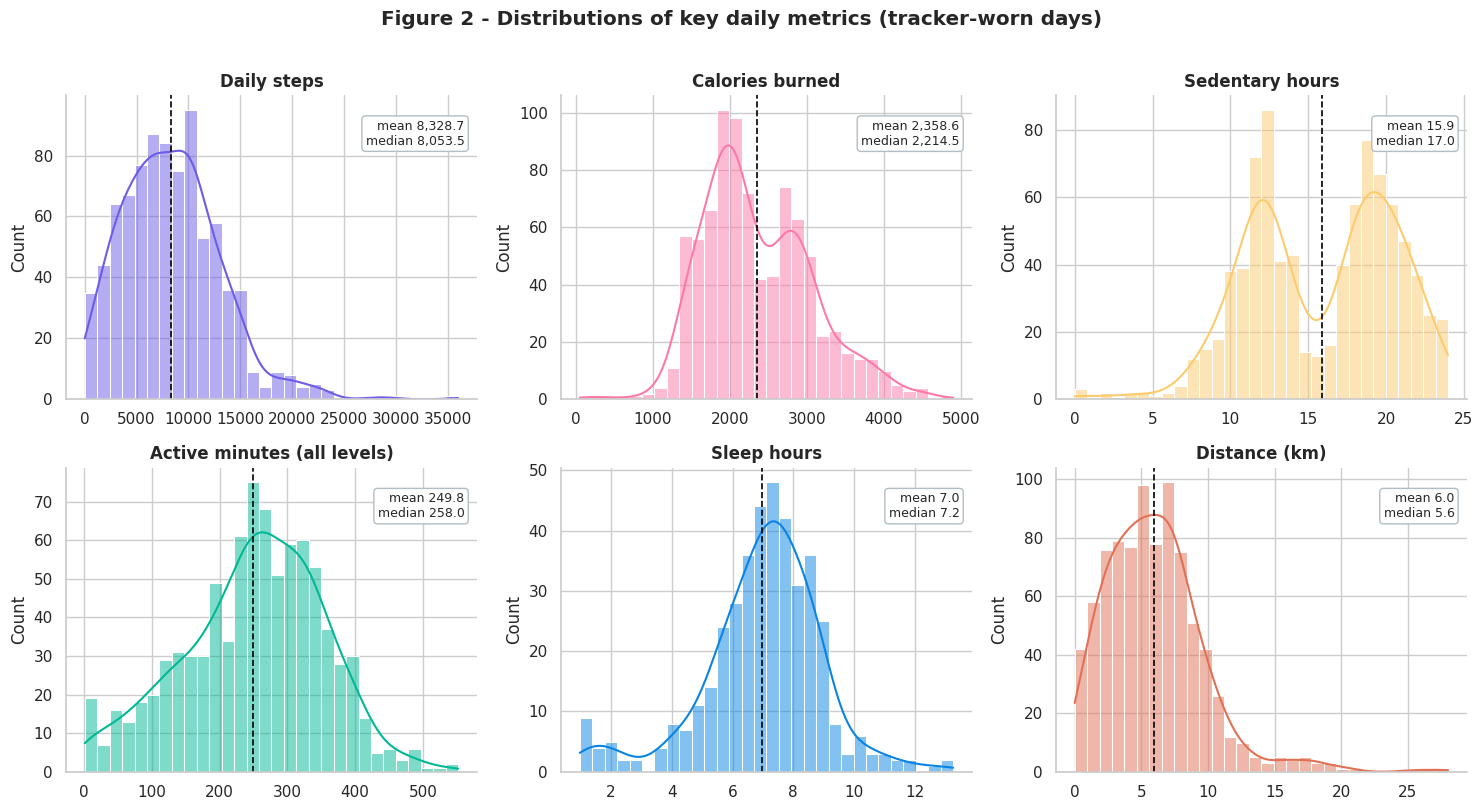

In [7]:
cols = [("TotalSteps", "Daily steps", PRIMARY), ("Calories", "Calories burned", PINK),
        ("SedentaryHours", "Sedentary hours", AMBER), ("ActiveMinutes", "Active minutes (all levels)", TEAL),
        ("SleepHours", "Sleep hours", "#0984E3"), ("TotalDistance", "Distance (km)", "#E17055")]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (c, t, colr) in zip(axes.ravel(), cols):
    s = clean[c].dropna()
    sns.histplot(s, bins=30, kde=True, color=colr, ax=ax)
    ax.axvline(s.mean(), color="black", ls="--", lw=1.2)
    ax.text(0.97, 0.92, f"mean {s.mean():,.1f}\nmedian {s.median():,.1f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, bbox=dict(fc="white", ec=GREY, boxstyle="round"))
    ax.set_title(t); ax.set_xlabel("")
fig.suptitle("Figure 2 - Distributions of key daily metrics (tracker-worn days)", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

Step outliers (1.5*IQR rule): 15 - kept, they are real high-activity days (long runs/walks), not sensor errors.


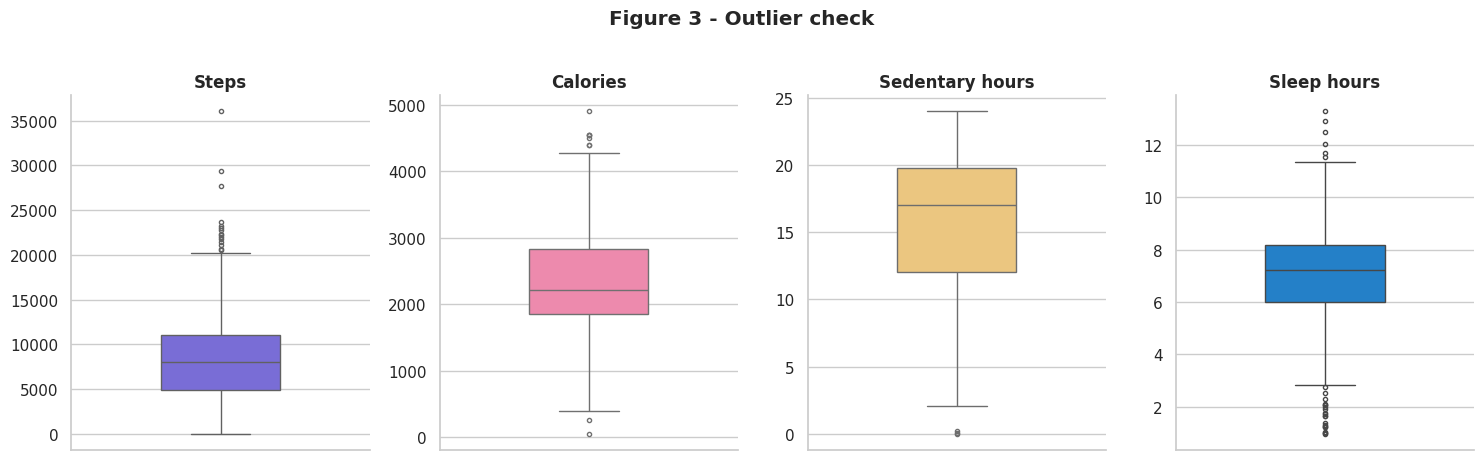

In [8]:
# Outlier check with boxplots
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, (c, t, colr) in zip(axes, [("TotalSteps", "Steps", PRIMARY), ("Calories", "Calories", PINK),
                                    ("SedentaryHours", "Sedentary hours", AMBER), ("SleepHours", "Sleep hours", "#0984E3")]):
    sns.boxplot(y=clean[c], color=colr, ax=ax, width=0.4, fliersize=3)
    ax.set_title(t); ax.set_ylabel("")
fig.suptitle("Figure 3 - Outlier check", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
q1, q3 = clean.TotalSteps.quantile([.25, .75]); iqr = q3 - q1
print("Step outliers (1.5*IQR rule):", ((clean.TotalSteps > q3 + 1.5 * iqr) | (clean.TotalSteps < q1 - 1.5 * iqr)).sum(),
      "- kept, they are real high-activity days (long runs/walks), not sensor errors.")

## 5. Weekday patterns

            steps  calories  sedentary_h  very_active  active  days
Weekday                                                            
Monday     8488.4    2381.0         16.4         25.4   252.3   109
Tuesday    8926.7    2433.9         16.1         25.8   264.2   135
Wednesday  8190.7    2338.2         15.8         22.6   243.2   138
Thursday   8185.4    2274.4         15.3         21.5   239.6   133
Friday     7820.6    2351.6         16.3         21.1   248.2   120
Saturday   8979.0    2426.4         15.4         24.0   270.1   112
Sunday     7668.9    2309.8         15.7         22.2   231.4   109


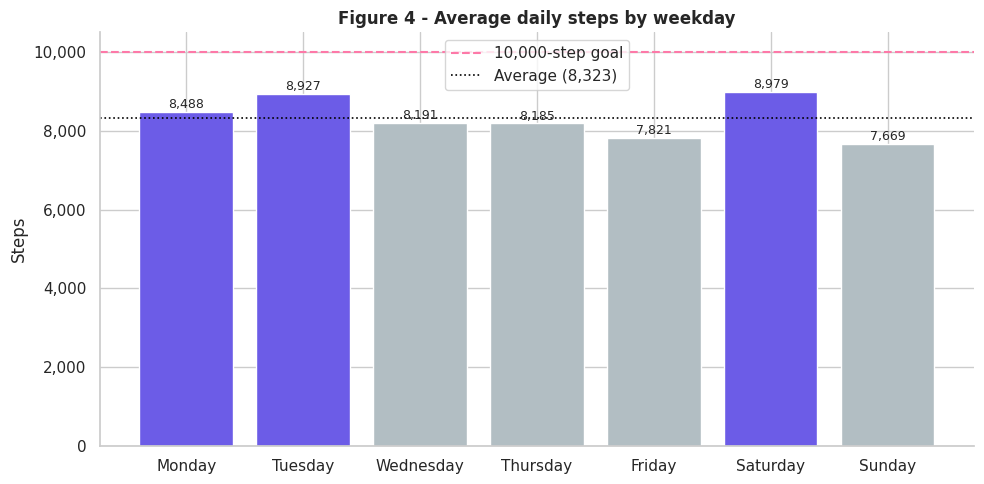

In [9]:
wk = clean.groupby("Weekday", observed=True).agg(steps=("TotalSteps", "mean"), calories=("Calories", "mean"),
        sedentary_h=("SedentaryHours", "mean"), very_active=("VeryActiveMinutes", "mean"),
        active=("ActiveMinutes", "mean"), days=("TotalSteps", "size")).round(1)
display(wk)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PRIMARY if v >= wk.steps.mean() else GREY for v in wk.steps]
bars = ax.bar(wk.index.astype(str), wk.steps, color=colors)
ax.axhline(10000, color=PINK, ls="--", lw=1.5, label="10,000-step goal")
ax.axhline(wk.steps.mean(), color="black", ls=":", lw=1.2, label=f"Average ({wk.steps.mean():,.0f})")
for b in bars: ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 100, f"{b.get_height():,.0f}", ha="center", fontsize=9)
ax.set_title("Figure 4 - Average daily steps by weekday"); ax.set_ylabel("Steps"); ax.legend()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

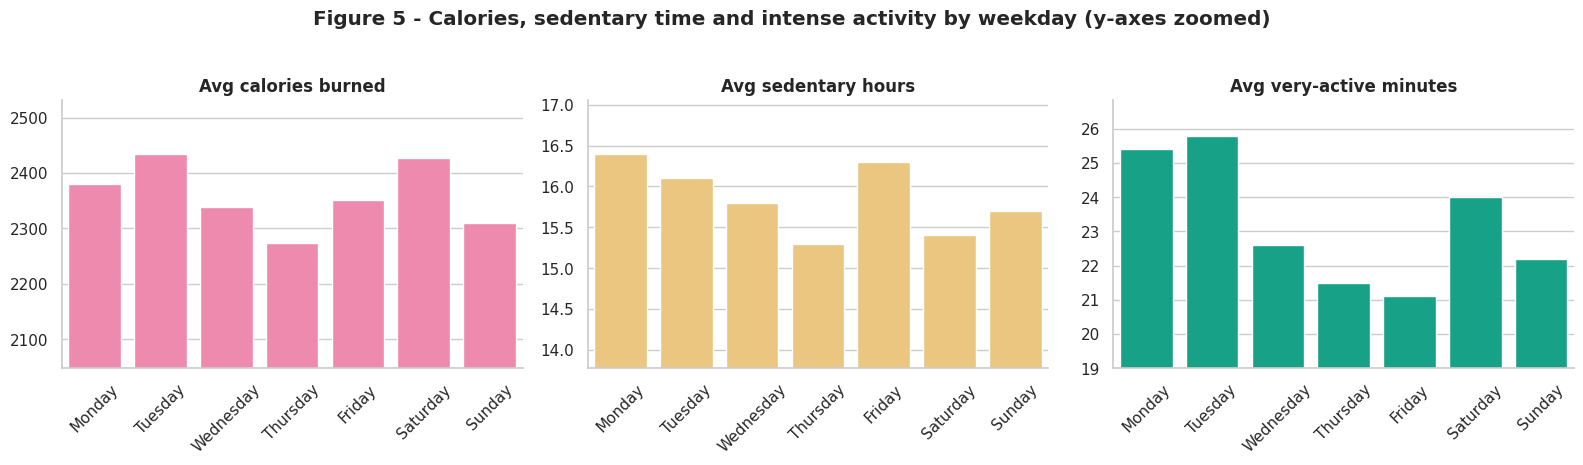

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (c, t, colr) in zip(axes, [("calories", "Avg calories burned", PINK), ("sedentary_h", "Avg sedentary hours", AMBER),
                                    ("very_active", "Avg very-active minutes", TEAL)]):
    sns.barplot(x=wk.index.astype(str), y=wk[c], color=colr, ax=ax)
    ax.set_title(t); ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=45)
    lo = wk[c].min() * 0.9; ax.set_ylim(lo, wk[c].max() * 1.04)
fig.suptitle("Figure 5 - Calories, sedentary time and intense activity by weekday (y-axes zoomed)", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

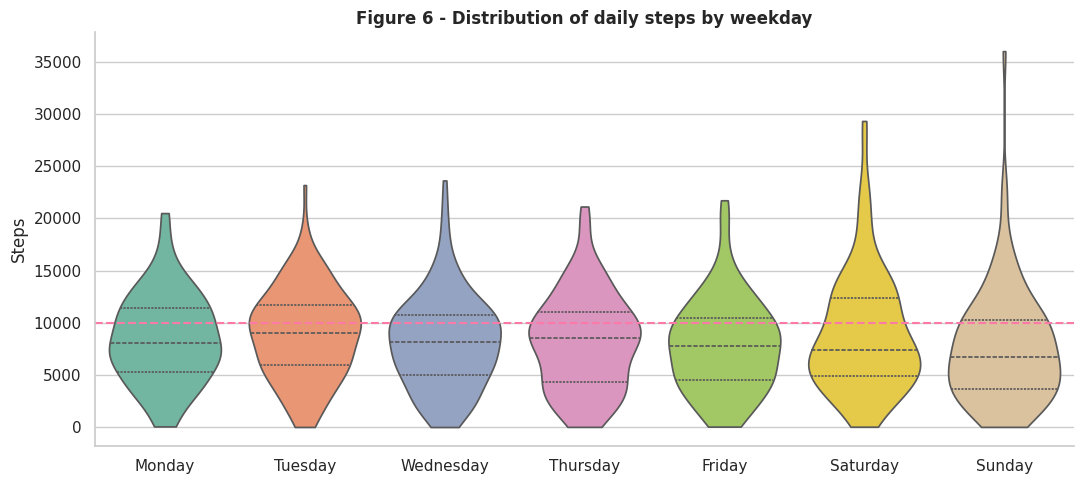

In [11]:
# Steps distribution per weekday (violin) - shows the spread hidden by averages
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=clean, x="Weekday", y="TotalSteps", order=WEEK, palette="Set2", inner="quartile", cut=0, ax=ax)
ax.axhline(10000, color=PINK, ls="--"); ax.set_title("Figure 6 - Distribution of daily steps by weekday")
ax.set_xlabel(""); ax.set_ylabel("Steps")
plt.tight_layout(); plt.show()

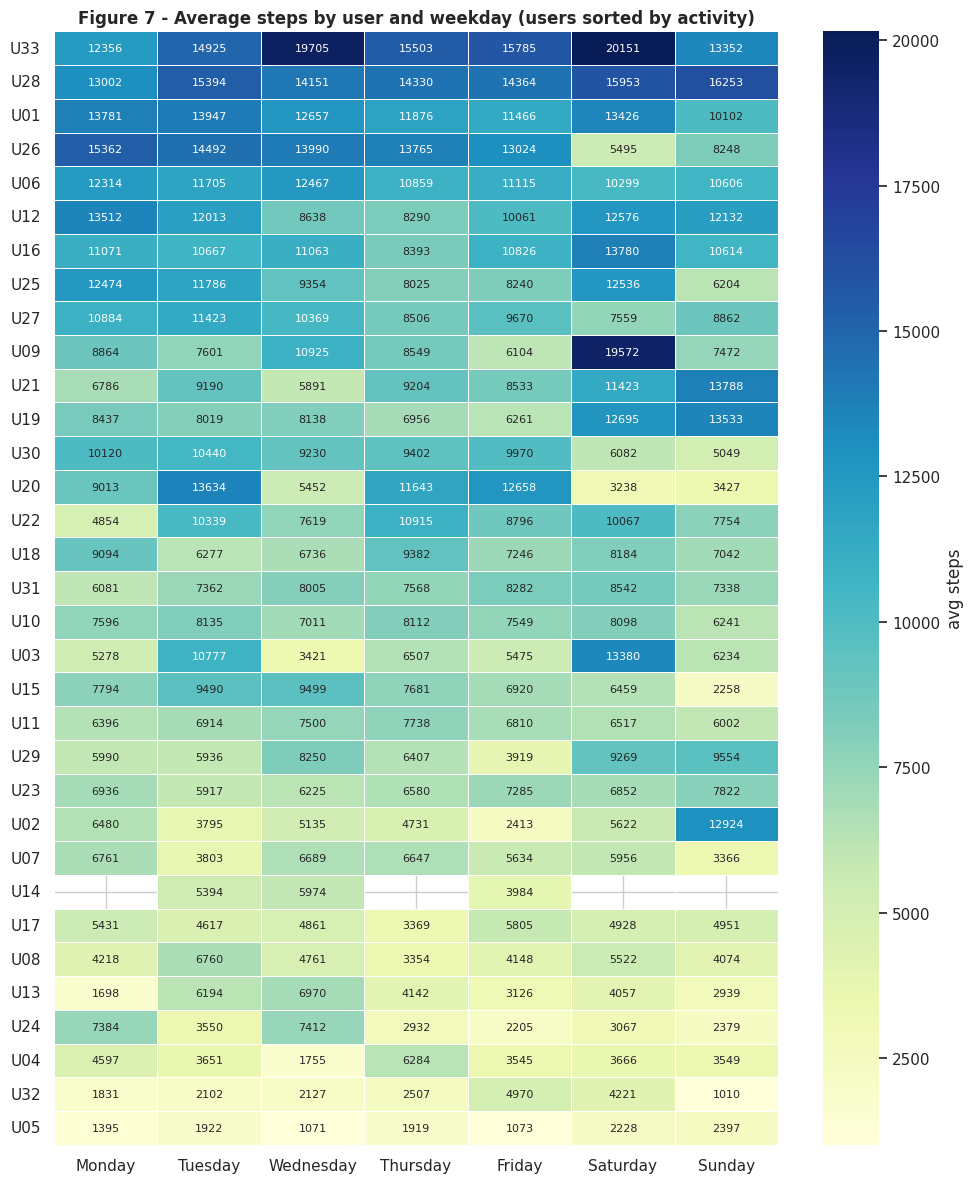

In [12]:
# Heatmap: every user x weekday (avg steps) - who is active and when?
order = clean.groupby("User")["TotalSteps"].mean().sort_values(ascending=False).index
pt = clean.pivot_table(index="User", columns="Weekday", values="TotalSteps", aggfunc="mean", observed=True).reindex(order)
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pt, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.4, cbar_kws={"label": "avg steps"}, ax=ax, annot_kws={"size": 8})
ax.set_title("Figure 7 - Average steps by user and weekday (users sorted by activity)"); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

         TotalSteps  Calories  SedentaryHours  SleepHours
DayType                                                  
Weekday     8327.24   2355.05           15.97        6.88
Weekend     8332.86   2368.86           15.55        7.26


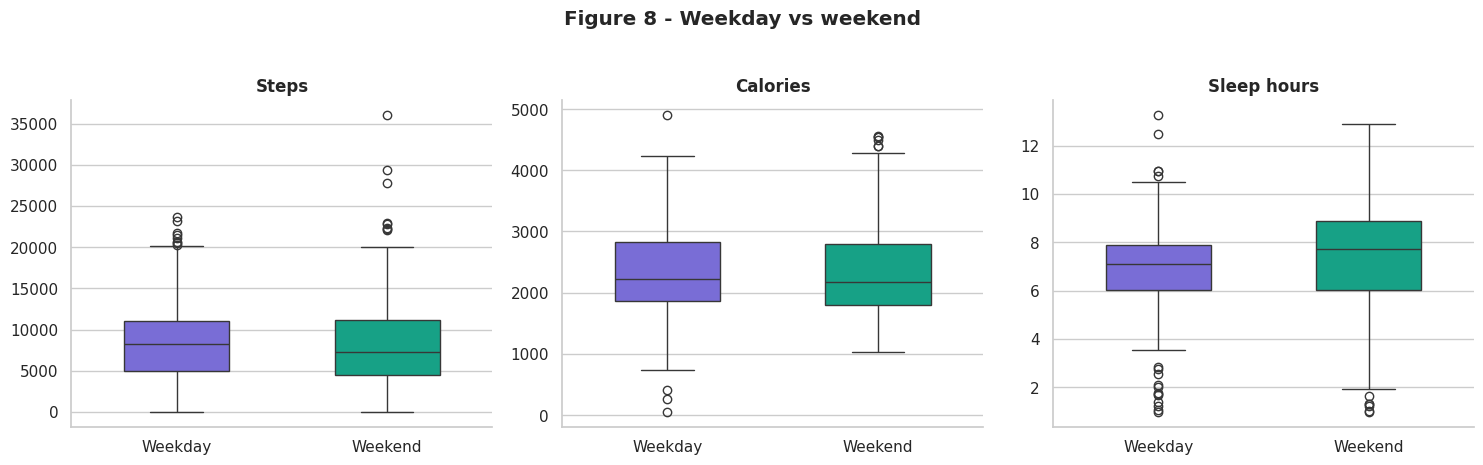

In [13]:
# Weekday vs weekend
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (c, t) in zip(axes, [("TotalSteps", "Steps"), ("Calories", "Calories"), ("SleepHours", "Sleep hours")]):
    sns.boxplot(data=clean, x="DayType", y=c, order=["Weekday", "Weekend"], palette=[PRIMARY, TEAL], ax=ax, width=.5)
    ax.set_title(t); ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Figure 8 - Weekday vs weekend", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
display(clean.groupby("DayType")[["TotalSteps", "Calories", "SedentaryHours", "SleepHours"]].mean().round(2))

**Insights - weekday patterns**
- Average steps are highest on **Saturday (~8,980) and Tuesday (~8,930)** and lowest on **Sunday (~7,670) and Friday (~7,820)**.
- Even the best day is **below the 10,000-step benchmark**; the average user never reaches the goal on any weekday.
- The violin plot shows a very wide spread within each day - user differences matter far more than day differences (see Section 14: weekday vs weekend is *not* statistically different).

## 6. Activity intensity & sedentary behaviour

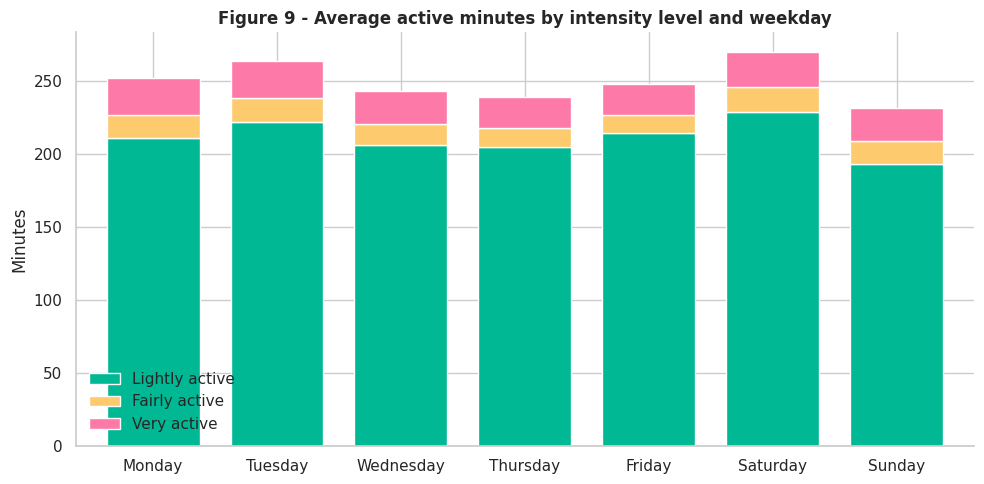

In [14]:
act = clean.groupby("Weekday", observed=True)[["LightlyActiveMinutes", "FairlyActiveMinutes", "VeryActiveMinutes"]].mean()
ax = act.plot(kind="bar", stacked=True, figsize=(10, 5), color=[TEAL, AMBER, PINK], width=.75)
ax.set_title("Figure 9 - Average active minutes by intensity level and weekday")
ax.set_ylabel("Minutes"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
ax.legend(["Lightly active", "Fairly active", "Very active"], frameon=False)
plt.tight_layout(); plt.show()

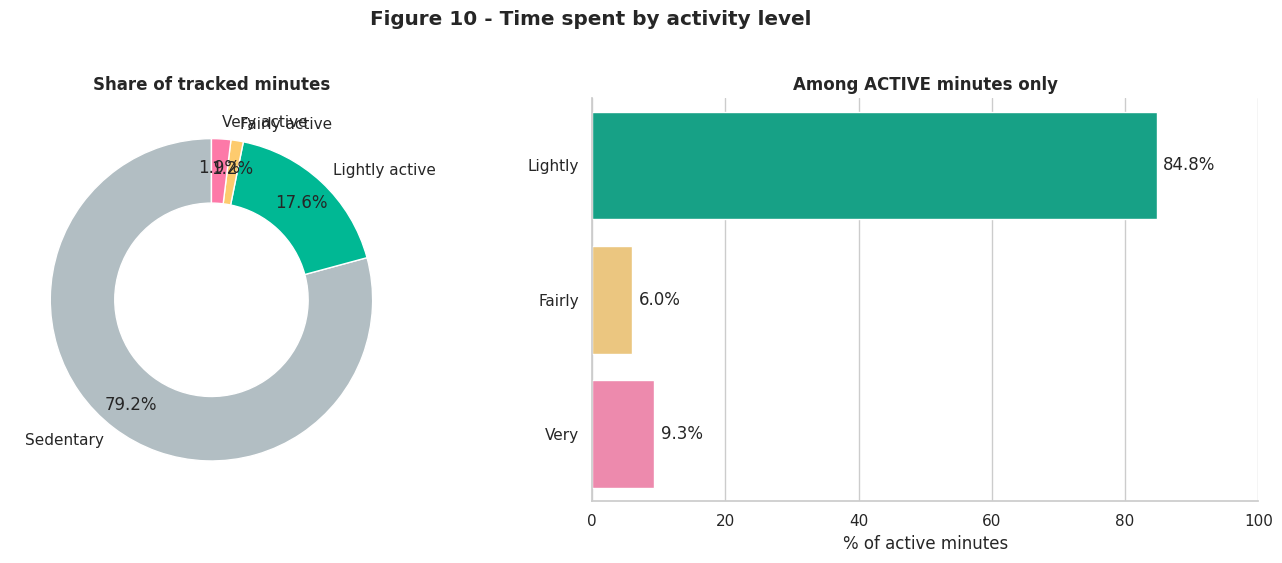

In [15]:
# How the 24 hours (1,440 min) are spent
split = clean[["SedentaryMinutes", "LightlyActiveMinutes", "FairlyActiveMinutes", "VeryActiveMinutes"]].sum()
labels = ["Sedentary", "Lightly active", "Fairly active", "Very active"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.1]})
axes[0].pie(split, labels=labels, autopct="%1.1f%%", startangle=90, pctdistance=.82, colors=[GREY, TEAL, AMBER, PINK],
            wedgeprops=dict(width=.4, edgecolor="white"))
axes[0].set_title("Share of tracked minutes")
active_only = split.iloc[1:] / split.iloc[1:].sum() * 100
sns.barplot(x=active_only.values, y=["Lightly", "Fairly", "Very"], palette=[TEAL, AMBER, PINK], ax=axes[1])
for i, v in enumerate(active_only.values): axes[1].text(v + 1, i, f"{v:.1f}%", va="center")
axes[1].set_title("Among ACTIVE minutes only"); axes[1].set_xlabel("% of active minutes"); axes[1].set_xlim(0, 100)
fig.suptitle("Figure 10 - Time spent by activity level", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

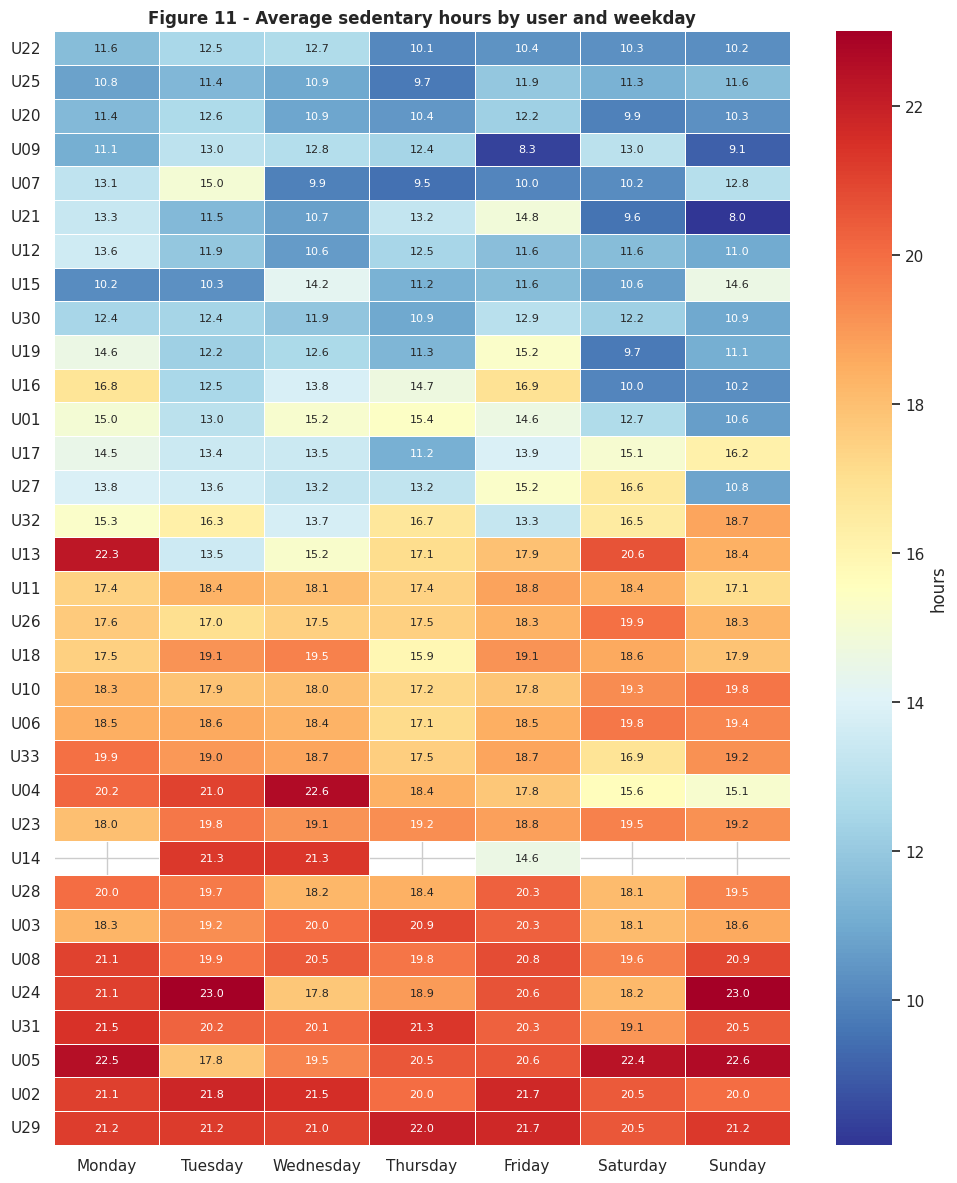

In [16]:
# Sedentary hours: user x weekday heatmap (red = sits more)
pt = clean.pivot_table(index="User", columns="Weekday", values="SedentaryHours", aggfunc="mean", observed=True)
pt = pt.loc[clean.groupby("User")["SedentaryHours"].mean().sort_values().index]
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pt, annot=True, fmt=".1f", cmap="RdYlBu_r", linewidths=.4, ax=ax, annot_kws={"size": 8}, cbar_kws={"label": "hours"})
ax.set_title("Figure 11 - Average sedentary hours by user and weekday"); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

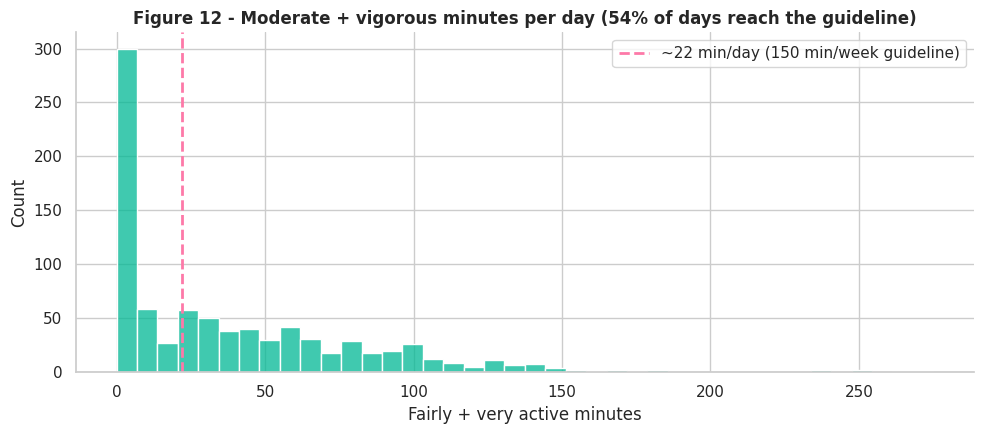

In [17]:
# WHO/CDC guideline: >=150 min/week moderate-to-vigorous -> ~22 min/day
clean["MVPA"] = clean["FairlyActiveMinutes"] + clean["VeryActiveMinutes"]
share = (clean["MVPA"] >= 22).mean()
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(clean["MVPA"], bins=40, color=TEAL, ax=ax)
ax.axvline(22, color=PINK, ls="--", lw=2, label="~22 min/day (150 min/week guideline)")
ax.set_title(f"Figure 12 - Moderate + vigorous minutes per day ({share:.0%} of days reach the guideline)")
ax.set_xlabel("Fairly + very active minutes"); ax.legend()
plt.tight_layout(); plt.show()

**Insights - intensity**
- Users are **sedentary for ~79% of tracked minutes (~16 hours/day)**.
- Of the active minutes, **~85% are only light activity**; fairly + very active time totals just ~38 minutes a day on average.
- Only about half of user-days reach the ~22 min/day moderate-to-vigorous guideline.
- Opportunity: a product/app that turns **light activity into moderate activity** (short guided sessions, "move reminders").

## 7. Users, segments & engagement

      avg_steps  avg_cal  sedentary_h  active_min  very_active  days_worn  goal_rate  sleep_h                  Segment
User                                                                                                                  
U33    16040.03  3420.26        18.55      310.71        66.06         31       0.90      NaN       Very active (10k+)
U28    14763.29  2945.81        19.13      245.71        85.16         31       0.87     4.95       Very active (10k+)
U01    12520.63  1876.97        13.81      287.07        40.00         30       0.90     6.00       Very active (10k+)
U26    12267.04  2686.12        17.98      355.38        33.62         24       0.75     1.14       Very active (10k+)
U06    11370.65  2509.97        18.54      313.10        36.29         31       0.87      NaN       Very active (10k+)
U12    10984.57  1513.67        11.79      254.93        18.90         30       0.73     4.89       Very active (10k+)
U16    10837.00  3098.50        13.61      281.9

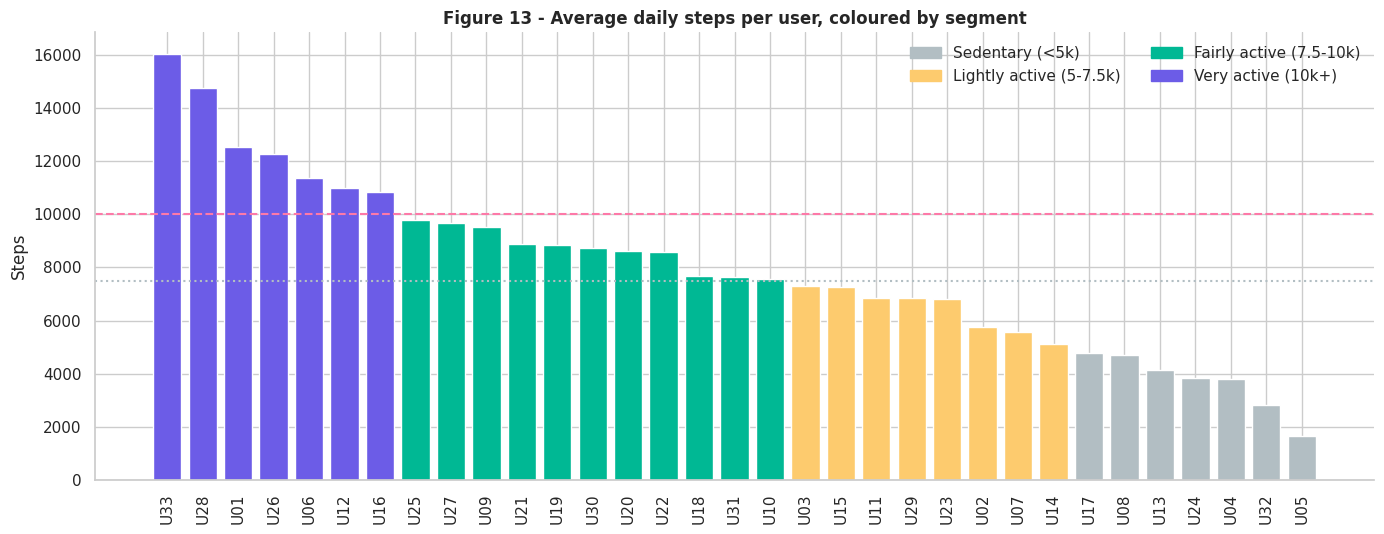

In [18]:
users = clean.groupby("User").agg(avg_steps=("TotalSteps", "mean"), avg_cal=("Calories", "mean"),
        sedentary_h=("SedentaryHours", "mean"), active_min=("ActiveMinutes", "mean"),
        very_active=("VeryActiveMinutes", "mean"), days_worn=("TotalSteps", "size"),
        goal_rate=("Met10k", "mean"), sleep_h=("SleepHours", "mean")).round(2)
users["Segment"] = pd.cut(users["avg_steps"], [0, 5000, 7500, 10000, np.inf],
                          labels=["Sedentary (<5k)", "Lightly active (5-7.5k)", "Fairly active (7.5-10k)", "Very active (10k+)"])
display(users.sort_values("avg_steps", ascending=False).head(8))

seg_colors = {"Sedentary (<5k)": GREY, "Lightly active (5-7.5k)": AMBER, "Fairly active (7.5-10k)": TEAL, "Very active (10k+)": PRIMARY}
u = users.sort_values("avg_steps", ascending=False)
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(u.index, u.avg_steps, color=[seg_colors[s] for s in u.Segment])
ax.axhline(10000, color=PINK, ls="--"); ax.axhline(7500, color=GREY, ls=":")
ax.set_title("Figure 13 - Average daily steps per user, coloured by segment"); ax.set_ylabel("Steps"); ax.tick_params(axis="x", rotation=90)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in seg_colors.values()]
ax.legend(handles, seg_colors.keys(), frameon=False, ncol=2)
plt.tight_layout(); plt.show()

                         users    steps  calories
Segment                                          
Sedentary (<5k)              7   3687.0    2161.0
Lightly active (5-7.5k)      8   6437.0    2063.0
Fairly active (7.5-10k)     11   8685.0    2511.0
Very active (10k+)           7  12683.0    2579.0


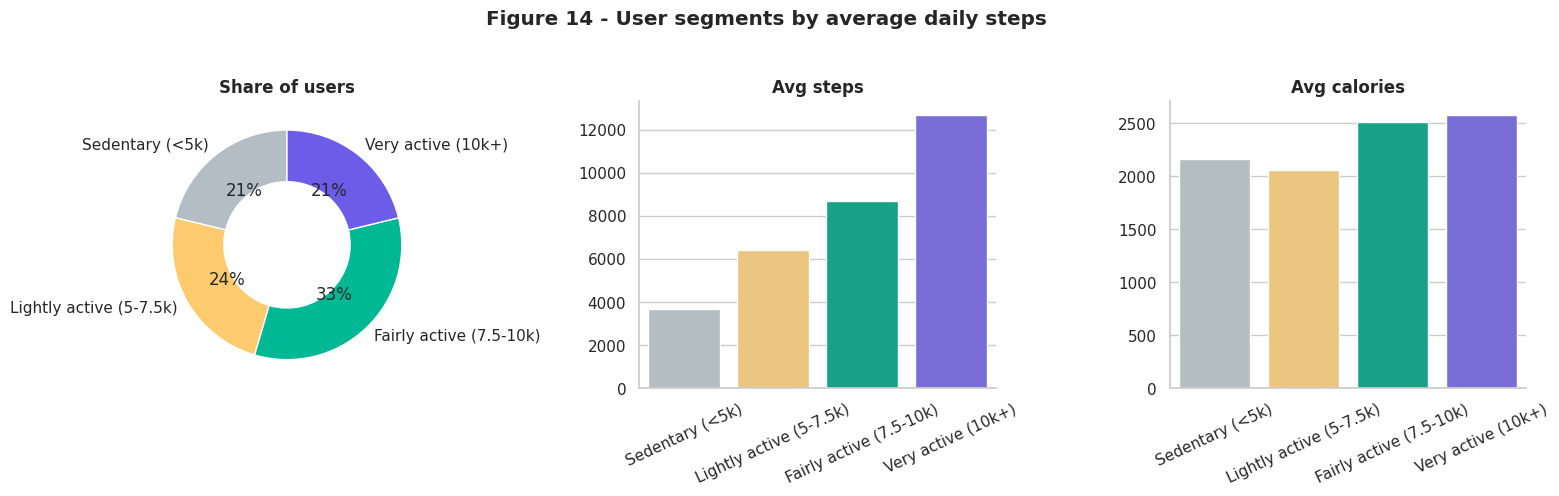

In [19]:
seg = users.groupby("Segment", observed=True).agg(users=("avg_steps", "size"), steps=("avg_steps", "mean"), calories=("avg_cal", "mean")).round(0)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].pie(seg.users, labels=seg.index, autopct=lambda p: f"{p:.0f}%", startangle=90, colors=list(seg_colors.values()),
            wedgeprops=dict(width=.45, edgecolor="white")); axes[0].set_title("Share of users")
sns.barplot(x=seg.index, y=seg.steps, palette=list(seg_colors.values()), ax=axes[1]); axes[1].set_title("Avg steps")
sns.barplot(x=seg.index, y=seg.calories, palette=list(seg_colors.values()), ax=axes[2]); axes[2].set_title("Avg calories")
for ax in axes[1:]: ax.tick_params(axis="x", rotation=25); ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Figure 14 - User segments by average daily steps", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
display(seg)

Days meeting 10,000 steps: 35.2% | users who NEVER hit it: 8 of 33


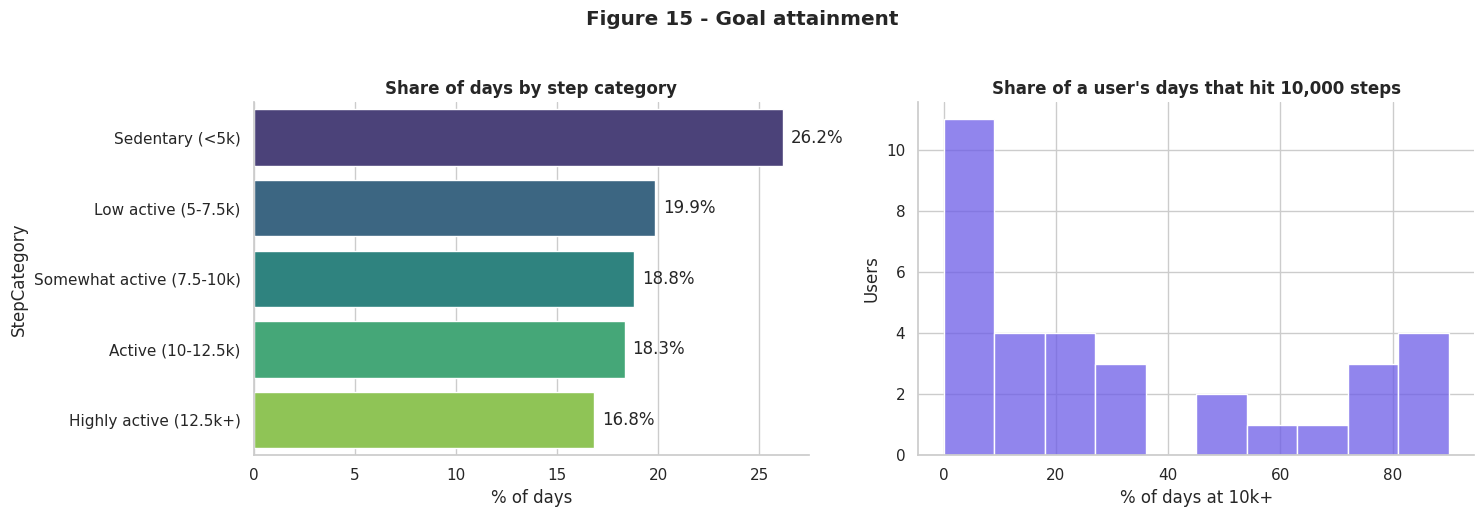

In [20]:
# Step categories at the DAY level + share of days meeting 10k
cat = clean["StepCategory"].value_counts(normalize=True).sort_index() * 100
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=cat.values, y=cat.index.astype(str), palette="viridis", ax=axes[0])
for i, v in enumerate(cat.values): axes[0].text(v + .4, i, f"{v:.1f}%", va="center")
axes[0].set_title("Share of days by step category"); axes[0].set_xlabel("% of days")
sns.histplot(users["goal_rate"] * 100, bins=10, color=PRIMARY, ax=axes[1])
axes[1].set_title("Share of a user's days that hit 10,000 steps"); axes[1].set_xlabel("% of days at 10k+"); axes[1].set_ylabel("Users")
fig.suptitle("Figure 15 - Goal attainment", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
print(f"Days meeting 10,000 steps: {clean.Met10k.mean():.1%} | users who NEVER hit it: {(users.goal_rate == 0).sum()} of {len(users)}")

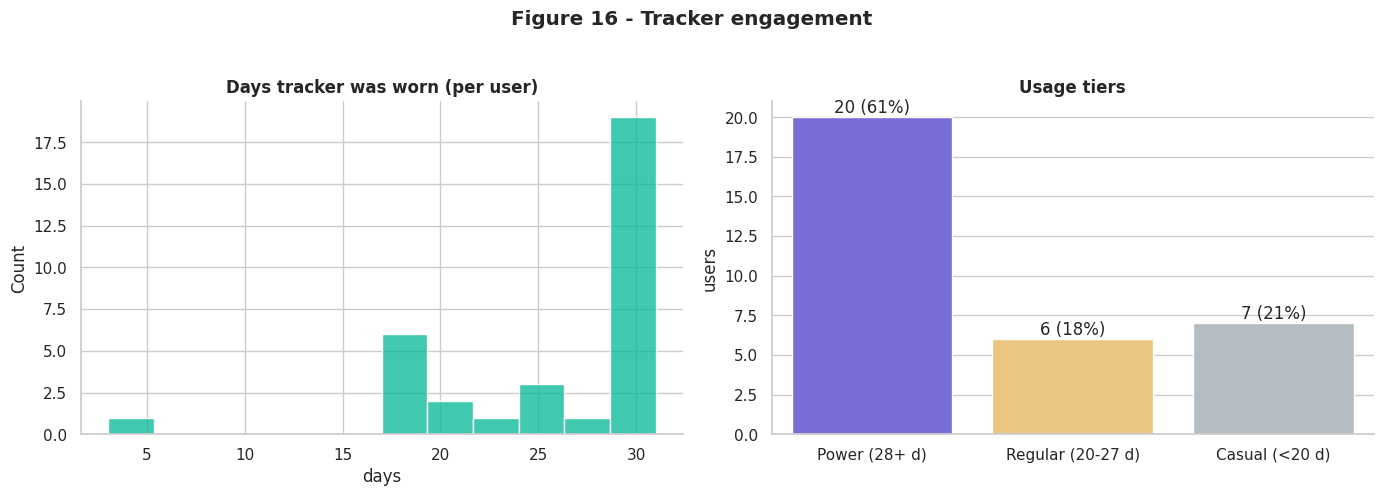

In [21]:
# Engagement: how consistently do people wear the tracker?  (31 possible days)
worn_days = df.groupby("User")["IsWorn"].sum()
tier = pd.cut(worn_days, [-1, 19, 27, 31], labels=["Casual (<20 d)", "Regular (20-27 d)", "Power (28+ d)"])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(worn_days, bins=12, color=TEAL, ax=axes[0]); axes[0].set_title("Days tracker was worn (per user)"); axes[0].set_xlabel("days")
t = tier.value_counts().reindex(["Power (28+ d)", "Regular (20-27 d)", "Casual (<20 d)"])
sns.barplot(x=t.index, y=t.values, palette=[PRIMARY, AMBER, GREY], ax=axes[1])
for i, v in enumerate(t.values): axes[1].text(i, v + .3, f"{v} ({v / t.sum():.0%})", ha="center")
axes[1].set_title("Usage tiers"); axes[1].set_xlabel(""); axes[1].set_ylabel("users")
fig.suptitle("Figure 16 - Tracker engagement", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

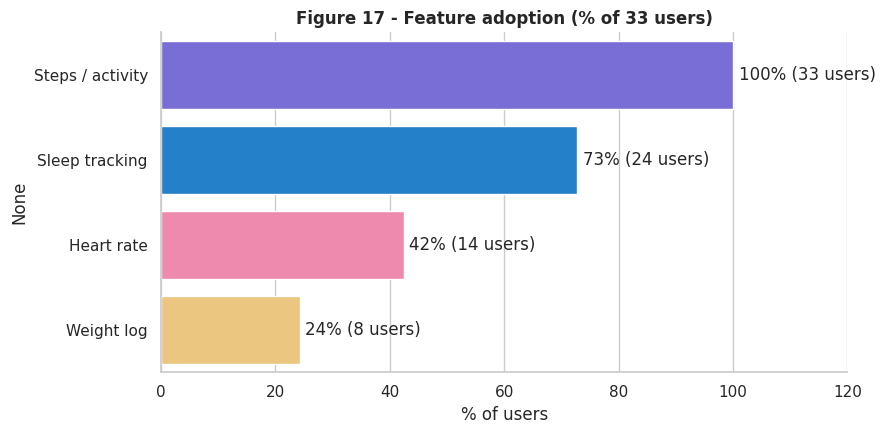

In [22]:
# Feature adoption: who uses sleep, heart rate and weight tracking?
adopt = pd.Series({"Steps / activity": df.User.nunique(), "Sleep tracking": df.loc[df.SleepHours.notna(), "User"].nunique(),
                   "Heart rate": df.loc[df.HR_Avg.notna(), "User"].nunique(), "Weight log": df.loc[df.WeightKg.notna(), "User"].nunique()})
pct = adopt / df.User.nunique() * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=pct.values, y=pct.index, palette=[PRIMARY, "#0984E3", PINK, AMBER], ax=ax)
for i, (v, n) in enumerate(zip(pct.values, adopt.values)): ax.text(v + 1, i, f"{v:.0f}% ({n} users)", va="center")
ax.set_xlim(0, 120); ax.set_title("Figure 17 - Feature adoption (% of 33 users)"); ax.set_xlabel("% of users")
plt.tight_layout(); plt.show()

**Insights - users**
- Users split roughly evenly: **~21% sedentary (<5k steps), ~24% lightly active, ~33% fairly active, ~21% very active (10k+)**.
- Only about **35% of days reach 10,000 steps**, and **8 of 33 users never reach it**.
- **~61% of users are power users** (28+ days worn) but ~21% wear the tracker fewer than 20 days - a retention gap.
- Adoption of secondary features is low: **sleep 73%, heart rate 42%, weight only 24%** - clear room for onboarding/nudges.

## 8. Sleep

Nights with sleep data: 410 | users: 24


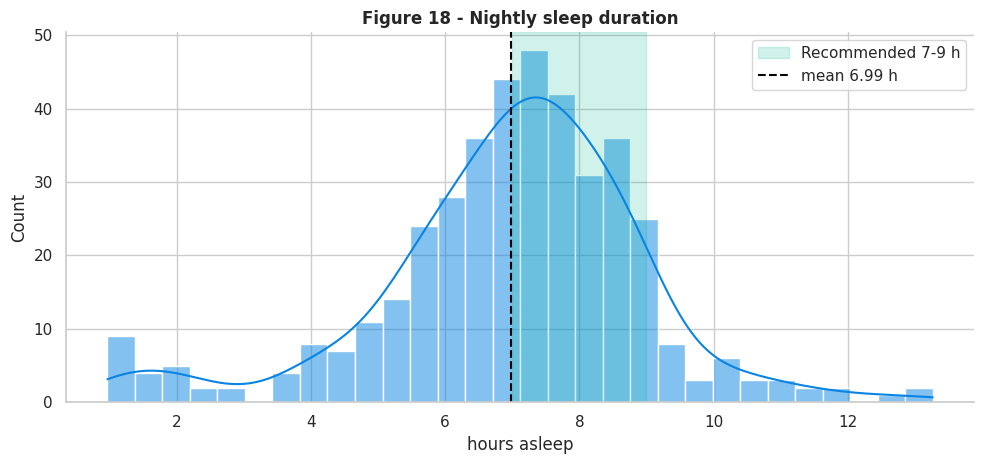

In [23]:
sl = clean.dropna(subset=["SleepHours"]).copy()
print("Nights with sleep data:", len(sl), "| users:", sl["User"].nunique())
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.histplot(sl["SleepHours"], bins=30, color="#0984E3", kde=True, ax=ax)
ax.axvspan(7, 9, color=TEAL, alpha=.18, label="Recommended 7-9 h")
ax.axvline(sl.SleepHours.mean(), color="black", ls="--", label=f"mean {sl.SleepHours.mean():.2f} h")
ax.set_title("Figure 18 - Nightly sleep duration"); ax.set_xlabel("hours asleep"); ax.legend()
plt.tight_layout(); plt.show()

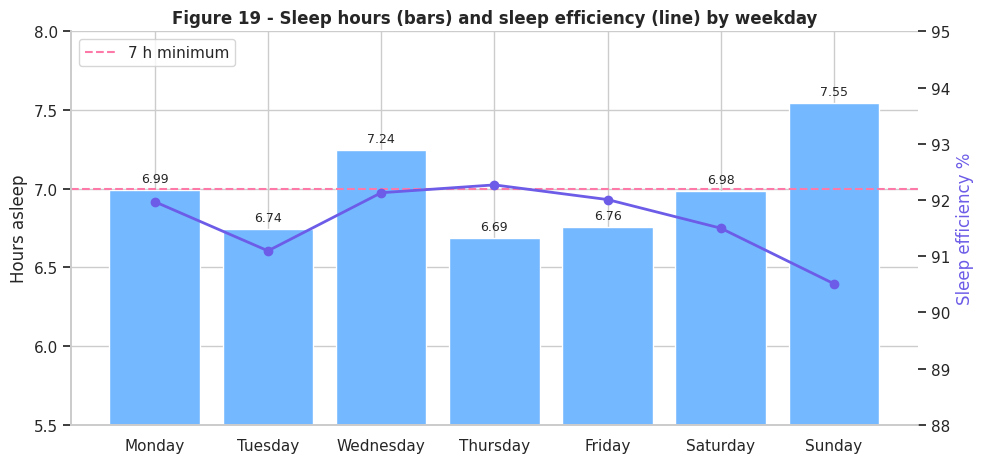

In [24]:
sw = sl.groupby("Weekday", observed=True).agg(hours=("SleepHours", "mean"), eff=("SleepEfficiency", "mean"))
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(sw.index.astype(str), sw.hours, color="#74B9FF")
ax.axhline(7, color=PINK, ls="--", label="7 h minimum")
for i, v in enumerate(sw.hours): ax.text(i, v + .05, f"{v:.2f}", ha="center", fontsize=9)
ax.set_ylim(5.5, 8); ax.set_ylabel("Hours asleep"); ax.legend(loc="upper left")
ax2 = ax.twinx(); ax2.plot(sw.index.astype(str), sw.eff, color=PRIMARY, marker="o", lw=2); ax2.set_ylabel("Sleep efficiency %", color=PRIMARY)
ax2.set_ylim(88, 95); ax2.grid(False)
ax.set_title("Figure 19 - Sleep hours (bars) and sleep efficiency (line) by weekday")
plt.tight_layout(); plt.show()

Average sleep efficiency: 91.6% | nights under 7 h: 44.1%


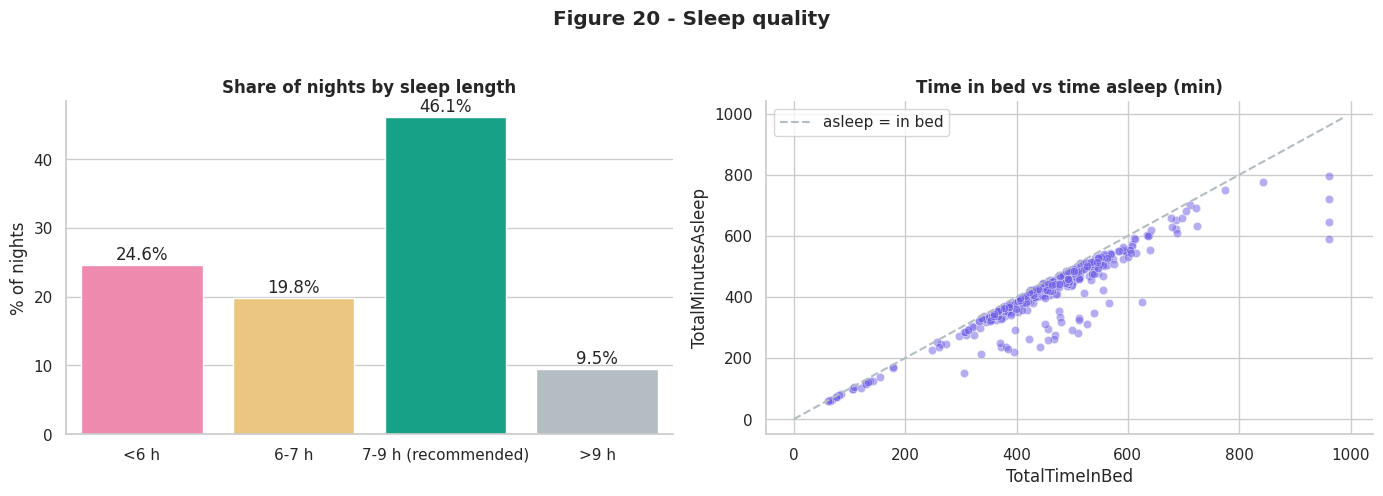

In [25]:
bucket = pd.cut(sl["SleepHours"], [0, 6, 7, 9, 24], labels=["<6 h", "6-7 h", "7-9 h (recommended)", ">9 h"]).value_counts(normalize=True).sort_index() * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(x=bucket.index, y=bucket.values, palette=[PINK, AMBER, TEAL, GREY], ax=axes[0])
for i, v in enumerate(bucket.values): axes[0].text(i, v + .8, f"{v:.1f}%", ha="center")
axes[0].set_title("Share of nights by sleep length"); axes[0].set_ylabel("% of nights"); axes[0].set_xlabel("")
sns.scatterplot(data=sl, x="TotalTimeInBed", y="TotalMinutesAsleep", alpha=.5, color=PRIMARY, ax=axes[1])
lim = [0, sl.TotalTimeInBed.max() + 30]; axes[1].plot(lim, lim, color=GREY, ls="--", label="asleep = in bed")
axes[1].set_title("Time in bed vs time asleep (min)"); axes[1].legend()
fig.suptitle("Figure 20 - Sleep quality", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
print(f"Average sleep efficiency: {sl.SleepEfficiency.mean():.1f}% | nights under 7 h: {(sl.SleepHours < 7).mean():.1%}")

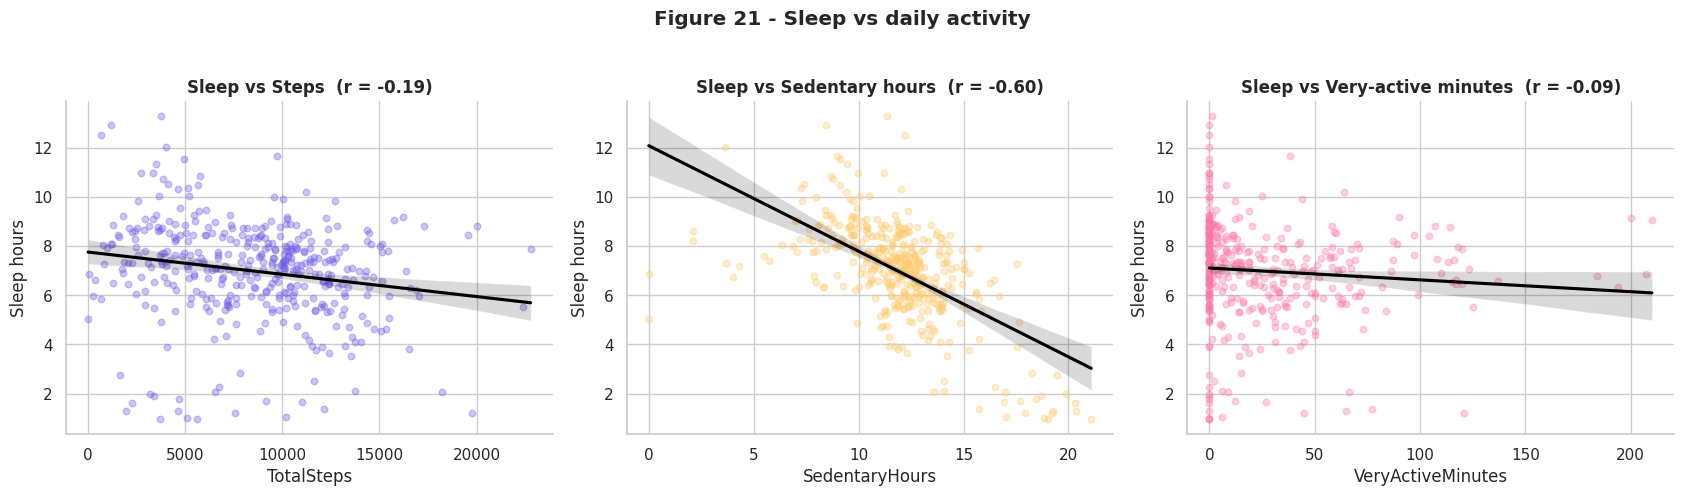

In [26]:
# Is sleep related to activity?
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (x, t, colr) in zip(axes, [("TotalSteps", "Steps", PRIMARY), ("SedentaryHours", "Sedentary hours", AMBER), ("VeryActiveMinutes", "Very-active minutes", PINK)]):
    sns.regplot(data=sl, x=x, y="SleepHours", scatter_kws=dict(alpha=.35, s=22, color=colr), line_kws=dict(color="black"), ax=ax)
    r = sl[[x, "SleepHours"]].corr().iloc[0, 1]; ax.set_title(f"Sleep vs {t}  (r = {r:.2f})"); ax.set_ylabel("Sleep hours")
fig.suptitle("Figure 21 - Sleep vs daily activity", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

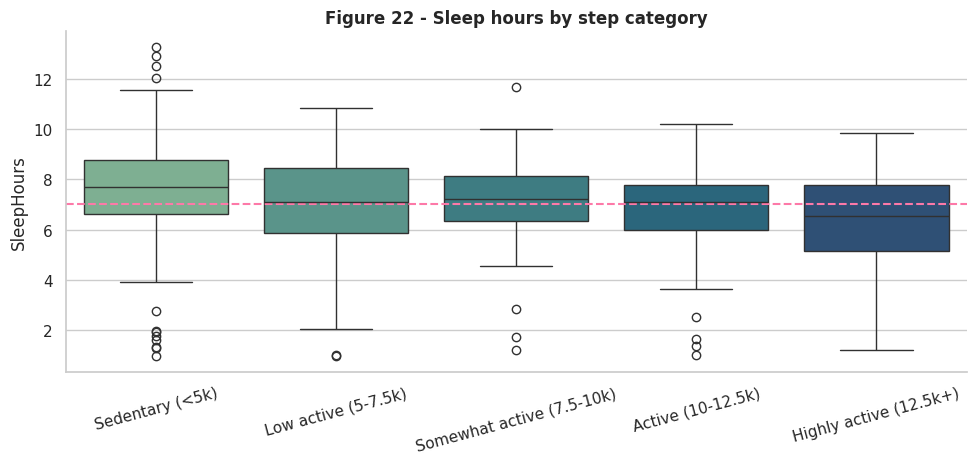

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.boxplot(data=sl, x="StepCategory", y="SleepHours", palette="crest", ax=ax)
ax.axhline(7, color=PINK, ls="--"); ax.set_title("Figure 22 - Sleep hours by step category"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

**Insights - sleep**
- Average sleep is **~7.0 hours**, but **~44% of nights are under 7 hours** and about a quarter are under 6.
- Sleep efficiency is high (**~92%**) - people fall asleep quickly; the problem is **going to bed too late / too short**, not restless sleep.
- Sunday nights are longest (~7.5 h) while Thursday is the shortest (~6.7 h).
- Sleep is **weakly negatively correlated** with steps (r ~ -0.19): the most active days are not followed by longer sleep, so activity alone will not fix sleep - a separate bedtime/wind-down feature is a real opportunity.

## 9. What drives calorie burn?

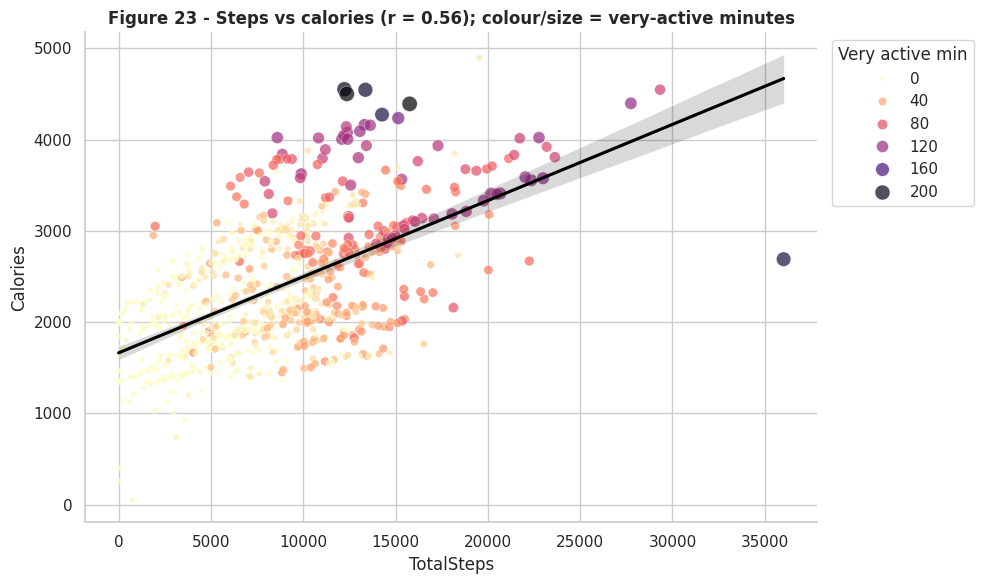

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=clean, x="TotalSteps", y="Calories", hue="VeryActiveMinutes", palette="magma_r", size="VeryActiveMinutes", sizes=(15, 120), alpha=.7, ax=ax)
sns.regplot(data=clean, x="TotalSteps", y="Calories", scatter=False, color="black", ax=ax)
r = clean[["TotalSteps", "Calories"]].corr().iloc[0, 1]
ax.set_title(f"Figure 23 - Steps vs calories (r = {r:.2f}); colour/size = very-active minutes")
ax.legend(title="Very active min", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

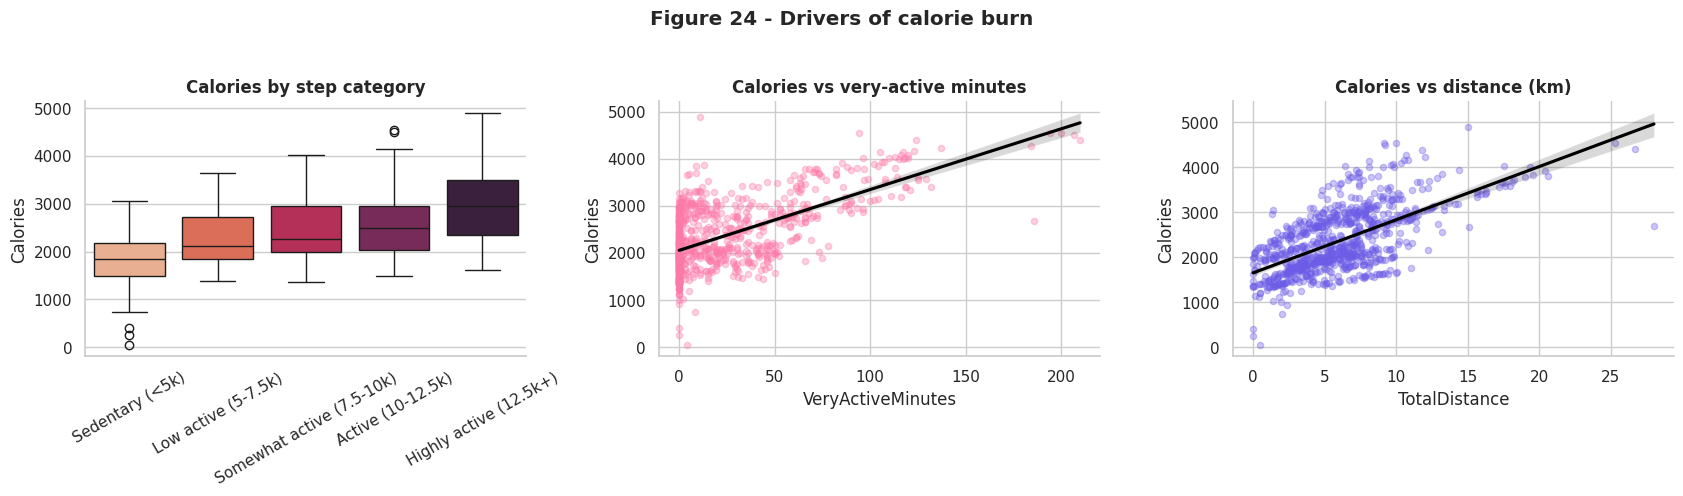

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sns.boxplot(data=clean, x="StepCategory", y="Calories", palette="rocket_r", ax=axes[0]); axes[0].tick_params(axis="x", rotation=30); axes[0].set_xlabel(""); axes[0].set_title("Calories by step category")
sns.regplot(data=clean, x="VeryActiveMinutes", y="Calories", scatter_kws=dict(alpha=.35, s=20, color=PINK), line_kws=dict(color="black"), ax=axes[1]); axes[1].set_title("Calories vs very-active minutes")
sns.regplot(data=clean, x="TotalDistance", y="Calories", scatter_kws=dict(alpha=.35, s=20, color=PRIMARY), line_kws=dict(color="black"), ax=axes[2]); axes[2].set_title("Calories vs distance (km)")
fig.suptitle("Figure 24 - Drivers of calorie burn", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

               variable      r     R2
1         TotalDistance  0.626  0.392
2     VeryActiveMinutes  0.617  0.381
0            TotalSteps  0.563  0.317
3   FairlyActiveMinutes  0.269  0.072
4  LightlyActiveMinutes  0.194  0.038
5      SedentaryMinutes -0.038  0.001


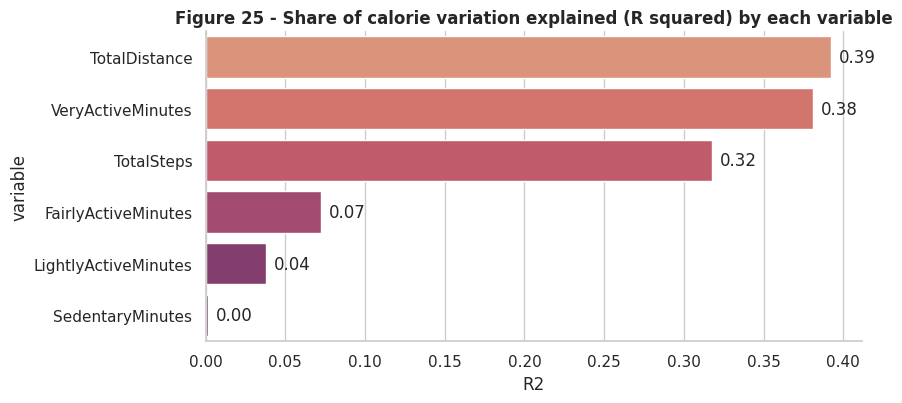

In [30]:
# Which single variable explains calories best? (simple linear R^2)
rows = []
for c in ["TotalSteps", "TotalDistance", "VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes", "SedentaryMinutes"]:
    r = clean[[c, "Calories"]].corr().iloc[0, 1]; rows.append((c, r, r ** 2))
rank = pd.DataFrame(rows, columns=["variable", "r", "R2"]).sort_values("R2", ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.barplot(data=rank, x="R2", y="variable", palette="flare", ax=ax)
for i, v in enumerate(rank.R2): ax.text(v + .005, i, f"{v:.2f}", va="center")
ax.set_title("Figure 25 - Share of calorie variation explained (R squared) by each variable")
plt.tight_layout(); plt.show()
display(rank.round(3))

**Insights - calories**
- Calories rise with steps (r ~ 0.56), but **very-active minutes and distance explain calories better than steps alone** - *intensity* matters, not just volume.
- Highly active days (12.5k+ steps) burn ~1,100 more calories than sedentary days (<5k).
- Baseline calorie burn is high even on inactive days (~1,850), so calorie goals should be framed relative to the user's own baseline.

## 10. Correlations

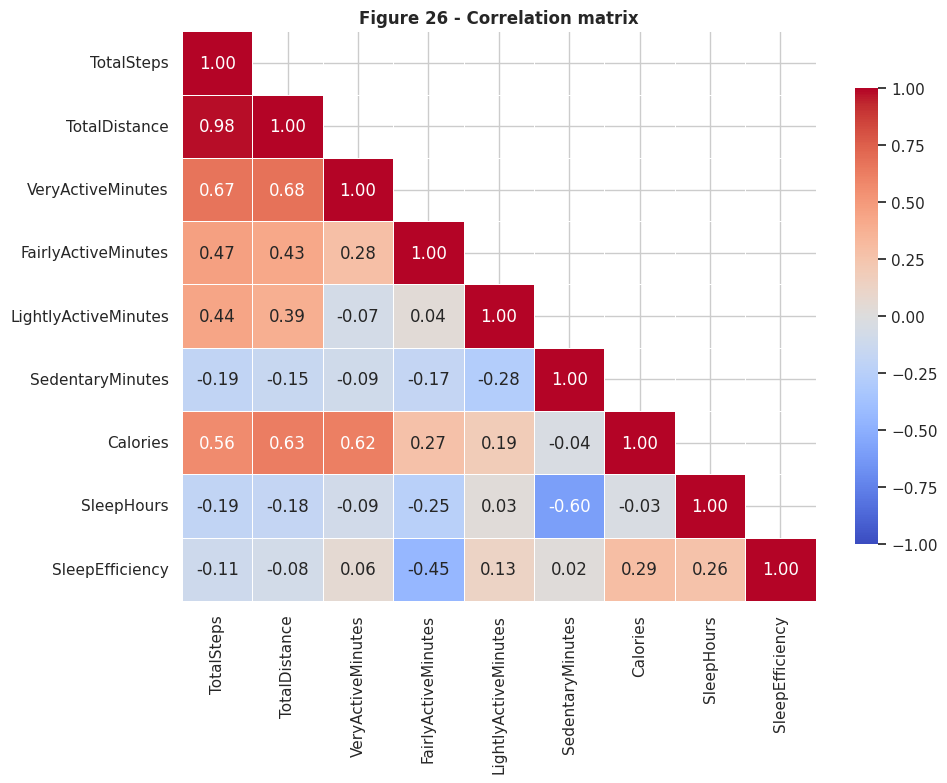

In [31]:
num = clean[["TotalSteps", "TotalDistance", "VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes",
             "SedentaryMinutes", "Calories", "SleepHours", "SleepEfficiency"]]
corr = num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=.5, ax=ax, cbar_kws={"shrink": .8})
ax.set_title("Figure 26 - Correlation matrix")
plt.tight_layout(); plt.show()

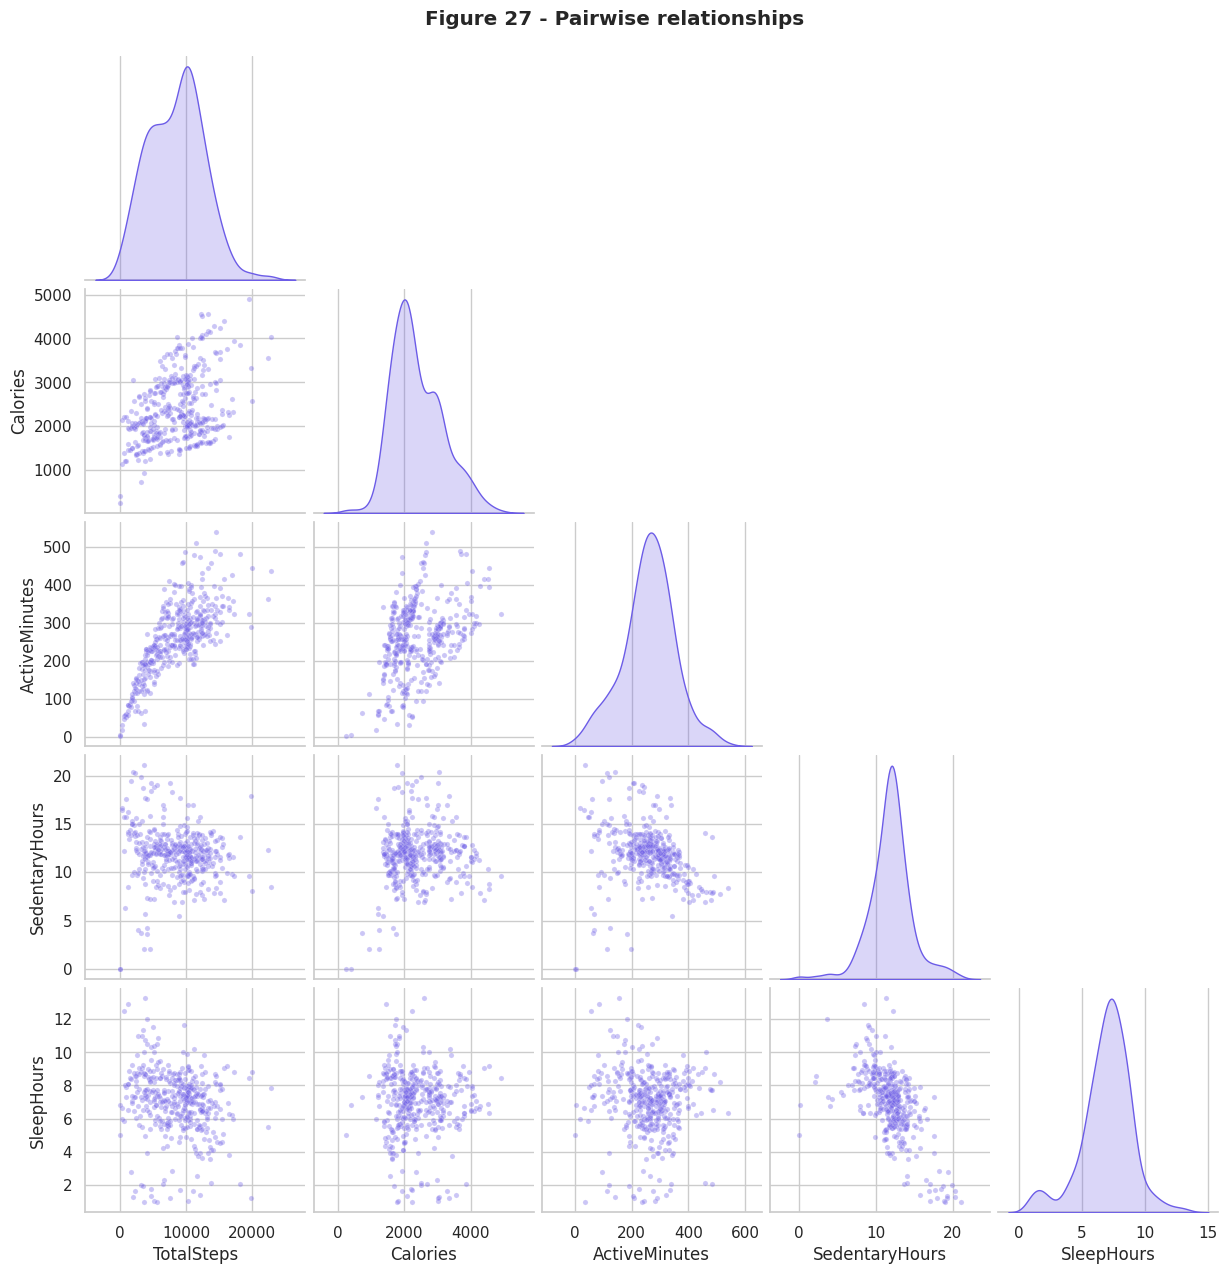

In [32]:
g = sns.pairplot(clean[["TotalSteps", "Calories", "ActiveMinutes", "SedentaryHours", "SleepHours"]].dropna(),
                 corner=True, diag_kind="kde", plot_kws=dict(alpha=.35, s=14, color=PRIMARY), diag_kws=dict(color=PRIMARY))
g.figure.suptitle("Figure 27 - Pairwise relationships", y=1.02, fontweight="bold")
plt.show()

## 11. Trends over time

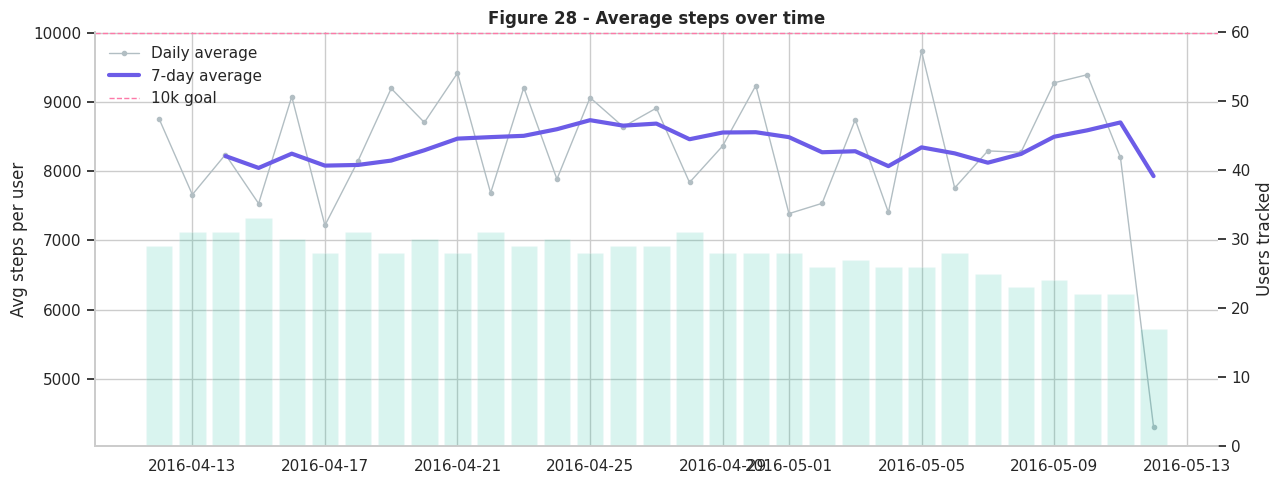

In [33]:
daily = clean.groupby("Date").agg(steps=("TotalSteps", "mean"), users=("User", "nunique"), sed=("SedentaryHours", "mean"))
daily["roll7"] = daily["steps"].rolling(7, min_periods=3).mean()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily.index, daily.steps, color=GREY, marker="o", ms=3, lw=1, label="Daily average")
ax.plot(daily.index, daily.roll7, color=PRIMARY, lw=3, label="7-day average")
ax.axhline(10000, color=PINK, ls="--", lw=1, label="10k goal")
ax.set_ylabel("Avg steps per user"); ax.set_title("Figure 28 - Average steps over time")
ax2 = ax.twinx(); ax2.bar(daily.index, daily.users, alpha=.15, color=TEAL); ax2.set_ylabel("Users tracked"); ax2.grid(False); ax2.set_ylim(0, 60)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

       steps     cal  users  days
Week                             
15    8078.0  2363.0     33   182
16    8586.0  2395.0     32   207
17    8487.0  2368.0     31   201
18    8248.0  2396.0     29   181
19    8036.0  2159.0     24    85


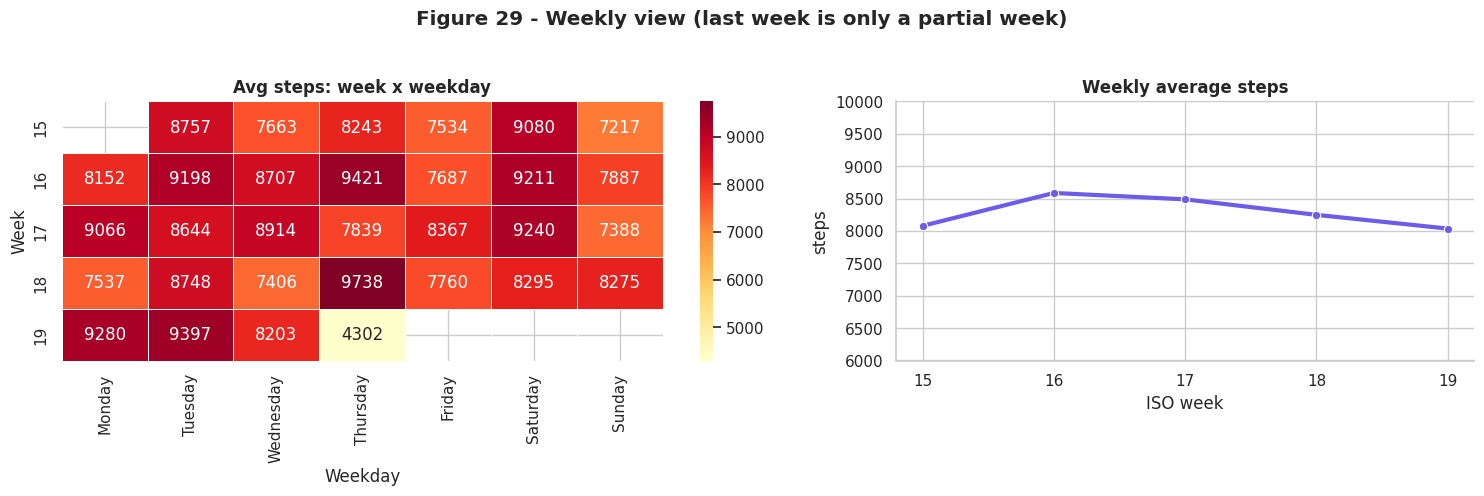

In [34]:
wkly = clean.groupby("Week").agg(steps=("TotalSteps", "mean"), cal=("Calories", "mean"), users=("User", "nunique"), days=("User", "size")).round(0)
display(wkly)
pt = clean.pivot_table(index="Week", columns="Weekday", values="TotalSteps", aggfunc="mean", observed=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.3, 1]})
sns.heatmap(pt, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0], linewidths=.4); axes[0].set_title("Avg steps: week x weekday")
sns.lineplot(x=wkly.index.astype(str), y=wkly.steps, marker="o", color=PRIMARY, ax=axes[1], lw=3); axes[1].set_title("Weekly average steps"); axes[1].set_xlabel("ISO week"); axes[1].set_ylim(6000, 10000)
fig.suptitle("Figure 29 - Weekly view (last week is only a partial week)", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

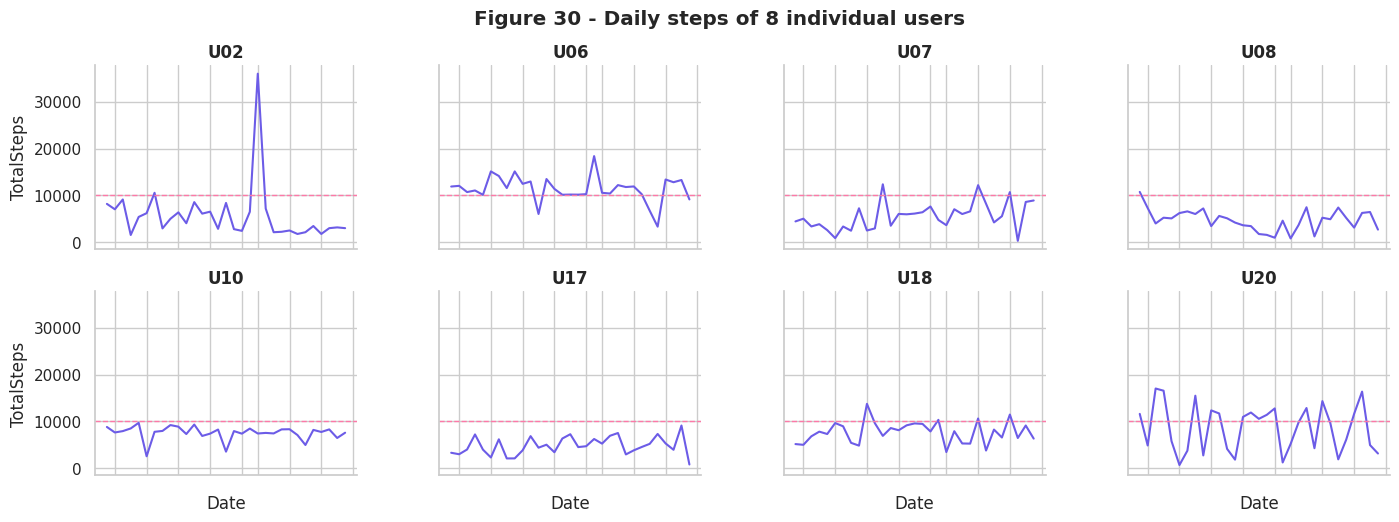

In [35]:
# Small multiples: the 8 users with the most data
top = clean["User"].value_counts().head(8).index
g = sns.FacetGrid(clean[clean.User.isin(top)], col="User", col_wrap=4, height=2.6, aspect=1.4, sharey=True)
g.map_dataframe(sns.lineplot, x="Date", y="TotalSteps", color=PRIMARY)
g.map(plt.axhline, y=10000, color=PINK, ls="--", lw=1)
g.set_titles("{col_name}"); g.set_xticklabels(rotation=45, fontsize=7)
g.figure.suptitle("Figure 30 - Daily steps of 8 individual users", y=1.03, fontweight="bold")
plt.show()

## 12. Heart rate & weight (small samples)

Heart-rate days: 332 | users: 14


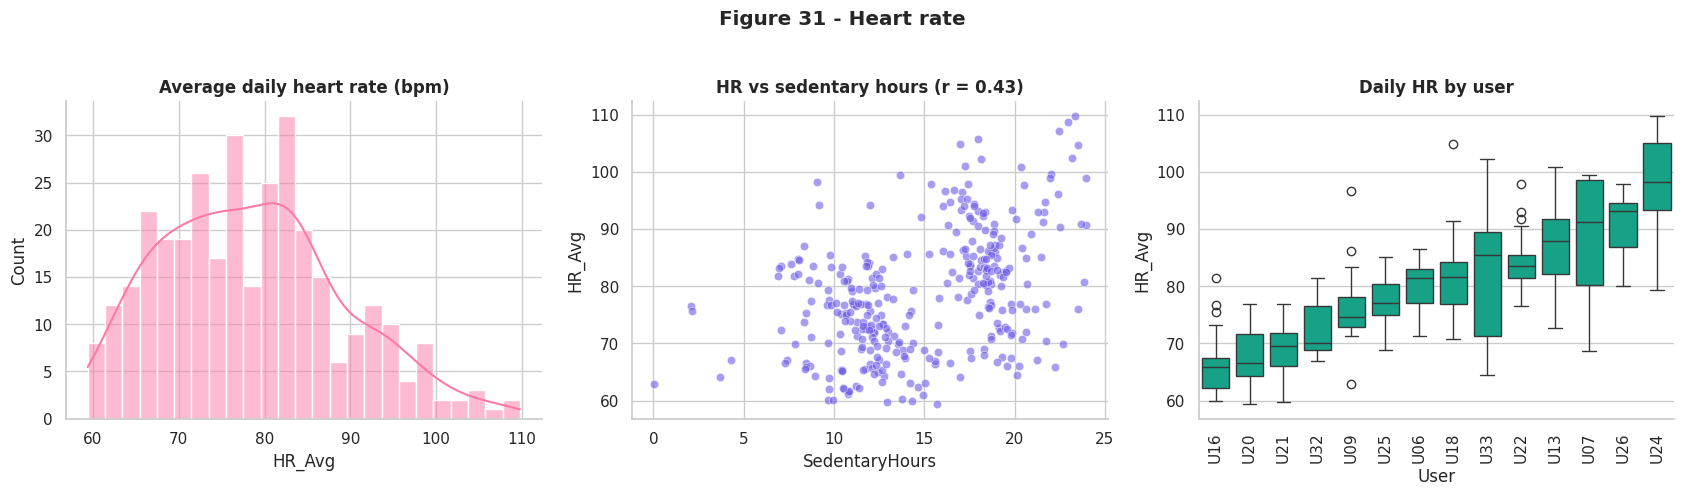

In [36]:
hr = clean.dropna(subset=["HR_Avg"])
print("Heart-rate days:", len(hr), "| users:", hr.User.nunique())
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sns.histplot(hr["HR_Avg"], bins=25, color=PINK, kde=True, ax=axes[0]); axes[0].set_title("Average daily heart rate (bpm)")
sns.scatterplot(data=hr, x="SedentaryHours", y="HR_Avg", color=PRIMARY, alpha=.6, ax=axes[1]); axes[1].set_title(f"HR vs sedentary hours (r = {hr[['SedentaryHours', 'HR_Avg']].corr().iloc[0, 1]:.2f})")
order = hr.groupby("User")["HR_Avg"].mean().sort_values().index
sns.boxplot(data=hr, x="User", y="HR_Avg", order=order, color=TEAL, ax=axes[2]); axes[2].set_title("Daily HR by user"); axes[2].tick_params(axis="x", rotation=90)
fig.suptitle("Figure 31 - Heart rate", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

Weight logs: 67 | users: 8
Manually entered weight logs: 61.0 %


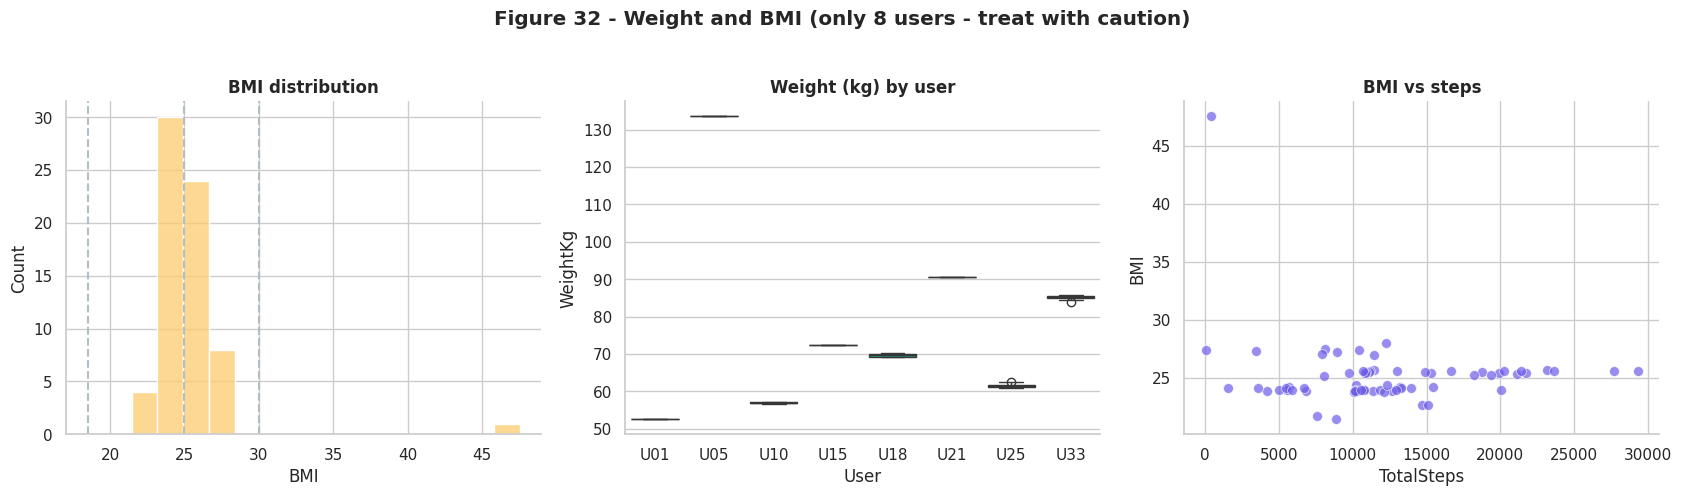

In [37]:
wt = clean.dropna(subset=["BMI"])
print("Weight logs:", len(wt), "| users:", wt.User.nunique())
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sns.histplot(wt["BMI"], bins=15, color=AMBER, ax=axes[0]); axes[0].set_title("BMI distribution")
for x, l in [(18.5, "18.5"), (25, "25"), (30, "30")]: axes[0].axvline(x, color=GREY, ls="--")
sns.boxplot(data=wt, x="User", y="WeightKg", color=TEAL, ax=axes[1]); axes[1].set_title("Weight (kg) by user")
sns.scatterplot(data=wt, x="TotalSteps", y="BMI", color=PRIMARY, s=50, alpha=.7, ax=axes[2]); axes[2].set_title("BMI vs steps")
fig.suptitle("Figure 32 - Weight and BMI (only 8 users - treat with caution)", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
print("Manually entered weight logs:", wt["WeightIsManual"].mean().round(2) * 100, "%")

**Insights - heart rate & weight:** heart-rate data covers only 14 users and weight/BMI only 8 (mostly **manual entries**), so these are too small for general conclusions. The useful business point: **automatic** weight sync (smart scale) is rarely used - a feature gap.

## 13. Clustering users (K-Means)

{2: 0.337, 3: 0.295, 4: 0.268, 5: 0.259, 6: 0.298, 7: 0.294}


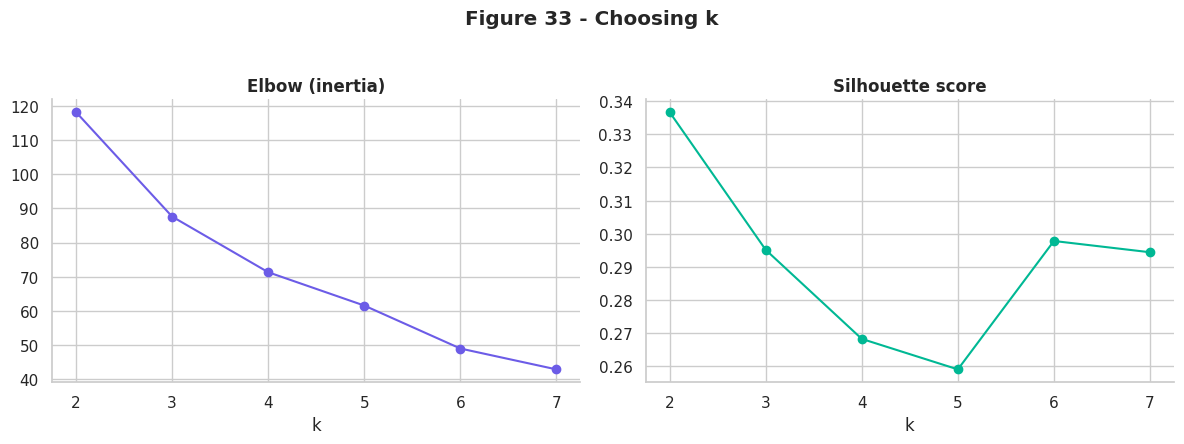

In [38]:
feat = users[["avg_steps", "avg_cal", "sedentary_h", "very_active", "days_worn", "goal_rate"]].copy()
X = StandardScaler().fit_transform(feat)
ks = range(2, 8)
inertia = [KMeans(k, n_init=10, random_state=42).fit(X).inertia_ for k in ks]
sil = [silhouette_score(X, KMeans(k, n_init=10, random_state=42).fit_predict(X)) for k in ks]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(list(ks), inertia, marker="o", color=PRIMARY); axes[0].set_title("Elbow (inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), sil, marker="o", color=TEAL); axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
fig.suptitle("Figure 33 - Choosing k", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()
print({k: round(s, 3) for k, s in zip(ks, sil)})

               users    steps  calories  sedentary_h  very_active  days_worn  goal_rate
Persona                                                                                
Low-activity      15   5504.0    2177.0         19.2          8.0       22.3        0.1
Moderate           9   8218.2    2066.8         11.8         10.7       28.3        0.4
High-activity      9  11677.6    2893.5         15.5         53.5       29.6        0.7


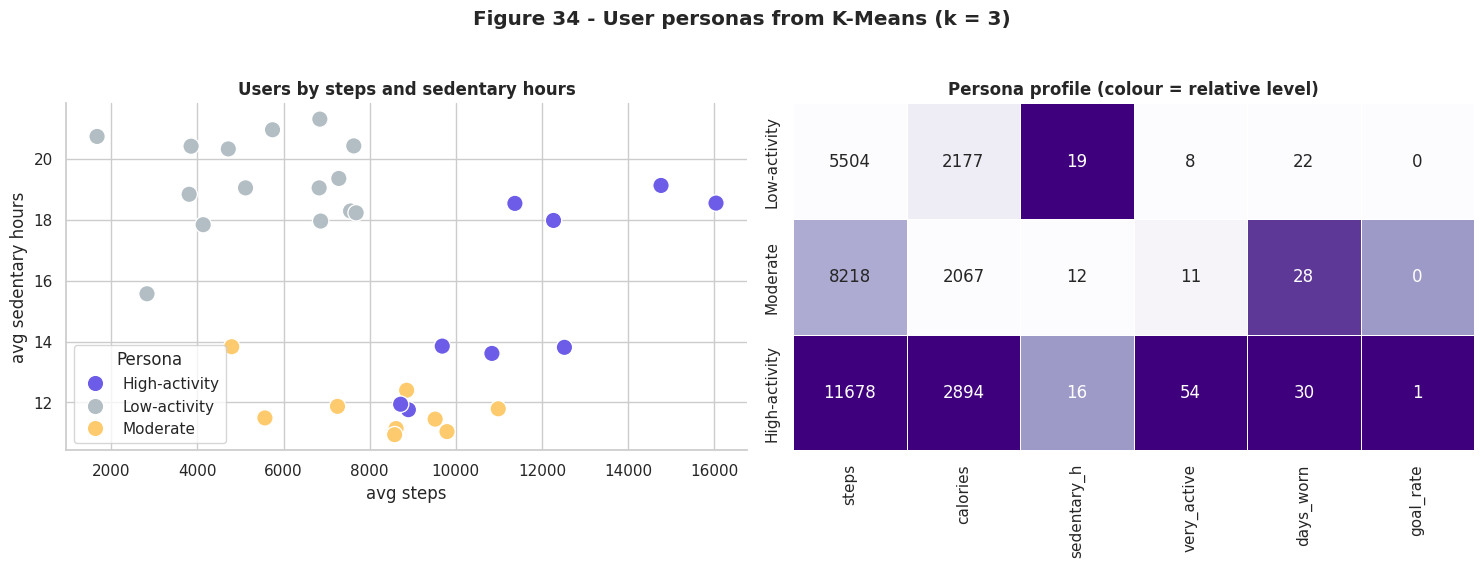

In [39]:
K = 3
km = KMeans(K, n_init=10, random_state=42).fit(X)
feat["cluster"] = km.labels_
rank = feat.groupby("cluster")["avg_steps"].mean().sort_values().index
names = dict(zip(rank, ["Low-activity", "Moderate", "High-activity"]))
feat["Persona"] = feat["cluster"].map(names)
prof = feat.groupby("Persona").agg(users=("avg_steps", "size"), steps=("avg_steps", "mean"), calories=("avg_cal", "mean"),
        sedentary_h=("sedentary_h", "mean"), very_active=("very_active", "mean"), days_worn=("days_worn", "mean"),
        goal_rate=("goal_rate", "mean")).round(1).reindex(["Low-activity", "Moderate", "High-activity"])
display(prof)

pal = {"Low-activity": GREY, "Moderate": AMBER, "High-activity": PRIMARY}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=feat, x="avg_steps", y="sedentary_h", hue="Persona", palette=pal, s=140, edgecolor="white", ax=axes[0])
axes[0].set_title("Users by steps and sedentary hours"); axes[0].set_xlabel("avg steps"); axes[0].set_ylabel("avg sedentary hours")
norm = (prof - prof.min()) / (prof.max() - prof.min())
sns.heatmap(norm.drop(columns="users"), annot=prof.drop(columns="users"), fmt=".0f", cmap="Purples", ax=axes[1], cbar=False, linewidths=.5)
axes[1].set_title("Persona profile (colour = relative level)"); axes[1].set_ylabel("")
fig.suptitle("Figure 34 - User personas from K-Means (k = 3)", fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

## 14. Statistical tests

In [40]:
we = clean[clean.DayType == "Weekend"]["TotalSteps"]; wd = clean[clean.DayType == "Weekday"]["TotalSteps"]
t, p = stats.ttest_ind(we, wd, equal_var=False)
print(f"1) Weekend vs weekday steps (Welch t-test): t = {t:.2f}, p = {p:.3f}  -> {'significant' if p < .05 else 'NOT significant'}")

F, p = stats.f_oneway(*[g["TotalSteps"] for _, g in clean.groupby("Weekday", observed=True)])
print(f"2) Steps across 7 weekdays (ANOVA):          F = {F:.2f}, p = {p:.3f}  -> {'significant' if p < .05 else 'NOT significant'}")

# Do users differ from each other? (between-user variation)
F, p = stats.f_oneway(*[g["TotalSteps"].values for _, g in clean.groupby("User")])
print(f"3) Steps across USERS (ANOVA):               F = {F:.1f}, p = {p:.2e} -> significant")

# Pearson correlations with p-values
rows = []
for a, b in [("TotalSteps", "Calories"), ("TotalSteps", "ActiveMinutes"), ("TotalSteps", "SedentaryMinutes"), ("TotalSteps", "SleepHours"), ("SedentaryHours", "SleepHours")]:
    s = clean[[a, b]].dropna(); r, p = stats.pearsonr(s[a], s[b]); rows.append((f"{a} vs {b}", len(s), round(r, 3), p))
display(pd.DataFrame(rows, columns=["pair", "n", "pearson_r", "p_value"]))

# Sleep <7h more likely on high-step days?  (chi-square)
sl2 = clean.dropna(subset=["SleepHours"]).copy()
ct = pd.crosstab(sl2["Met10k"], sl2["SleepHours"] < 7)
chi, p, *_ = stats.chi2_contingency(ct)
print(f"4) Hit 10k steps vs sleeping <7h (chi-square): p = {p:.3f}")
display(ct)

1) Weekend vs weekday steps (Welch t-test): t = 0.01, p = 0.989  -> NOT significant
2) Steps across 7 weekdays (ANOVA):          F = 1.35, p = 0.234  -> NOT significant
3) Steps across USERS (ANOVA):               F = 21.5, p = 4.06e-87 -> significant
                             pair    n  pearson_r        p_value
0          TotalSteps vs Calories  856      0.563   7.673290e-73
1     TotalSteps vs ActiveMinutes  856      0.717  4.495172e-136
2  TotalSteps vs SedentaryMinutes  856     -0.188   2.831548e-08
3        TotalSteps vs SleepHours  410     -0.190   1.053558e-04
4    SedentaryHours vs SleepHours  410     -0.601   1.252194e-41
4) Hit 10k steps vs sleeping <7h (chi-square): p = 0.010
SleepHours  False  True 
Met10k                  
False         150     95
True           79     86


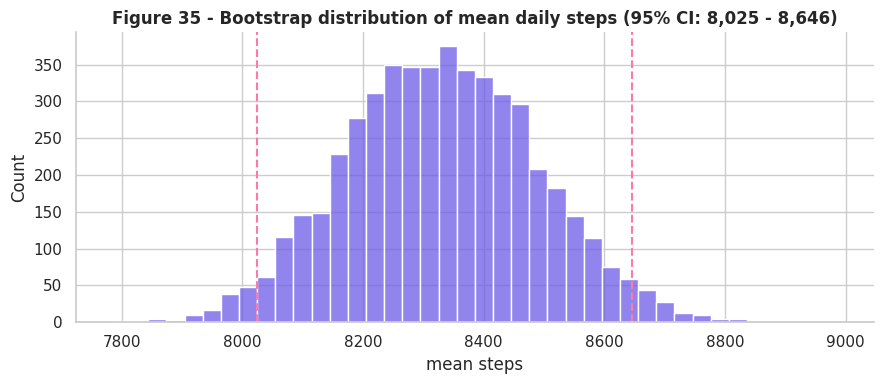

In [41]:
# Bootstrap 95% confidence interval for the average daily steps
rng = np.random.default_rng(42)
boot = [rng.choice(clean.TotalSteps, len(clean)).mean() for _ in range(5000)]
lo, hi = np.percentile(boot, [2.5, 97.5])
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(boot, bins=40, color=PRIMARY, ax=ax); ax.axvline(lo, color=PINK, ls="--"); ax.axvline(hi, color=PINK, ls="--")
ax.set_title(f"Figure 35 - Bootstrap distribution of mean daily steps (95% CI: {lo:,.0f} - {hi:,.0f})"); ax.set_xlabel("mean steps")
plt.tight_layout(); plt.show()

## 15. Key findings & recommendations for Bellabeat

### What the data says
| # | Finding | Evidence |
|---|---|---|
| 1 | Most days fall short of the 10k-step benchmark | only ~35% of days; 8 of 33 users never reach it |
| 2 | Users are sedentary ~16 h/day | ~79% of tracked minutes; ~85% of active minutes are light intensity |
| 3 | Activity is driven by *who the user is*, not the day | weekday vs weekend p ~ 0.99; between-user ANOVA highly significant |
| 4 | Sleep is short, not restless | ~44% of nights < 7 h, but efficiency ~92% |
| 5 | Intensity beats volume for calories | very-active minutes / distance explain calories better than steps |
| 6 | Secondary features are under-used | sleep 73%, heart rate 42%, weight 24% of users |
| 7 | ~1 in 5 users are casual wearers | 7 users wore the tracker < 20 of 31 days |

### Recommendations
1. **Position the Bellabeat app around "move a little more, more often"** - light-activity users are the majority; nudge them into 10-20 minutes of moderate activity with short guided sessions and hourly stand/move reminders (Leaf / Time wearables).
2. **Personalised step goals** instead of a flat 10k - segments (sedentary, light, fairly, very active) each need a different next milestone.
3. **Sleep programme**: bedtime reminders and wind-down routines aimed at the ~44% who sleep under 7 hours - efficiency is fine, so target *bedtime*, not sleep quality.
4. **Retention**: re-engage casual users (< 20 days) with streaks, weekly summaries and Membership content.
5. **Feature adoption**: promote heart-rate, and automatic weight/wellness syncing - only a minority use them today.
6. **Marketing message**: "Every step counts" for beginners; performance/intensity messaging for the already-active 21%.

### Limitations
- 33 users, 31 days, unknown age/gender (not necessarily Bellabeat's audience), 2016 data.
- Sleep, heart-rate and weight are available only for subsets of users.
- Correlation does not imply causation.